In [1]:
# ======================================================================
# PART 1: DATA UPLOAD & EVENT PREPARATION
# Multivariate Hawkes Process Modeling of Order Flow
# ======================================================================

import pandas as pd
import numpy as np
import os
from google.colab import files

print("=" * 70)
print("PART 1: DATA UPLOAD & EVENT PREPARATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. UPLOAD DATA
# ----------------------------------------------------------------------

print("\nUpload BTCUSDT TRADE + DEPTH files")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(" -", filename)


# ----------------------------------------------------------------------
# 2. IDENTIFY FILES
# ----------------------------------------------------------------------

trade_file = None
depth_file = None

for filename in uploaded.keys():

    name = filename.lower()

    if "trade" in name:
        trade_file = filename

    elif "depth" in name:
        depth_file = filename


print("\n" + "=" * 70)
print("FILE IDENTIFICATION")
print("=" * 70)

print("Trade file:", trade_file)
print("Depth file:", depth_file)


if trade_file is None:
    raise ValueError("Trade file not found.")

if depth_file is None:
    raise ValueError("Depth file not found.")


# ----------------------------------------------------------------------
# 3. LOAD DATA
# ----------------------------------------------------------------------

trades = pd.read_csv(trade_file)
depth = pd.read_csv(depth_file)

print("\n" + "=" * 70)
print("DATASET SHAPES")
print("=" * 70)

print("Trades:", trades.shape)
print("Depth :", depth.shape)


# ----------------------------------------------------------------------
# 4. DISPLAY COLUMNS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRADE COLUMNS")
print("=" * 70)

print(trades.columns.tolist())

print("\n" + "=" * 70)
print("DEPTH COLUMNS")
print("=" * 70)

print(depth.columns.tolist())


# ----------------------------------------------------------------------
# 5. DISPLAY SAMPLE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRADE SAMPLE")
print("=" * 70)

display(trades.head())

print("\n" + "=" * 70)
print("DEPTH SAMPLE")
print("=" * 70)

display(depth.head())


# ----------------------------------------------------------------------
# 6. STANDARDIZE COLUMN NAMES
# ----------------------------------------------------------------------

trades.columns = (
    trades.columns
    .str.strip()
    .str.lower()
)

depth.columns = (
    depth.columns
    .str.strip()
    .str.lower()
)

print("\nStandardized trade columns:")
print(trades.columns.tolist())

print("\nStandardized depth columns:")
print(depth.columns.tolist())


# ----------------------------------------------------------------------
# 7. CHECK REQUIRED TRADE COLUMNS
# ----------------------------------------------------------------------

required_trade_columns = [
    "timestamp",
    "price",
    "quantity",
    "buyer_maker"
]

missing_trade = [
    col for col in required_trade_columns
    if col not in trades.columns
]

if missing_trade:
    raise ValueError(
        f"Missing trade columns: {missing_trade}"
    )


# ----------------------------------------------------------------------
# 8. CONVERT TRADE DATA TYPES
# ----------------------------------------------------------------------

trades["timestamp"] = pd.to_numeric(
    trades["timestamp"],
    errors="coerce"
)

trades["price"] = pd.to_numeric(
    trades["price"],
    errors="coerce"
)

trades["quantity"] = pd.to_numeric(
    trades["quantity"],
    errors="coerce"
)


# ----------------------------------------------------------------------
# 9. REMOVE INVALID TRADE OBSERVATIONS
# ----------------------------------------------------------------------

trades = trades.dropna(
    subset=["timestamp", "price", "quantity"]
).copy()


# ----------------------------------------------------------------------
# 10. CONVERT TIMESTAMP
# ----------------------------------------------------------------------

# Detect milliseconds vs microseconds automatically

timestamp_median = trades["timestamp"].median()

if timestamp_median > 1e14:

    trades["datetime"] = pd.to_datetime(
        trades["timestamp"],
        unit="us",
        errors="coerce"
    )

    timestamp_unit = "microseconds"

elif timestamp_median > 1e11:

    trades["datetime"] = pd.to_datetime(
        trades["timestamp"],
        unit="ms",
        errors="coerce"
    )

    timestamp_unit = "milliseconds"

else:

    trades["datetime"] = pd.to_datetime(
        trades["timestamp"],
        unit="s",
        errors="coerce"
    )

    timestamp_unit = "seconds"


print("\nTimestamp unit detected:", timestamp_unit)


# ----------------------------------------------------------------------
# 11. SORT CHRONOLOGICALLY
# ----------------------------------------------------------------------

trades = (
    trades
    .sort_values("timestamp")
    .reset_index(drop=True)
)

depth = (
    depth
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------
# 12. IDENTIFY TRADE EVENT TYPE
# ----------------------------------------------------------------------

# Binance buyer_maker convention:
#
# buyer_maker = True
#     aggressive SELL
#
# buyer_maker = False
#     aggressive BUY

trades["event_type"] = np.where(
    trades["buyer_maker"].astype(str).str.lower().isin(
        ["true", "1"]
    ),
    "market_sell",
    "market_buy"
)


# ----------------------------------------------------------------------
# 13. BASIC EVENT STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT DISTRIBUTION")
print("=" * 70)

print(
    trades["event_type"]
    .value_counts()
)


# ----------------------------------------------------------------------
# 14. TRADE SIZE STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRADE QUANTITY STATISTICS")
print("=" * 70)

print(
    trades["quantity"].describe()
)


# ----------------------------------------------------------------------
# 15. TIME RANGE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TIME RANGE")
print("=" * 70)

print("Start:", trades["datetime"].min())
print("End  :", trades["datetime"].max())


# ----------------------------------------------------------------------
# 16. INTER-ARRIVAL TIMES
# ----------------------------------------------------------------------

trades["interarrival_seconds"] = (
    trades["timestamp"]
    .diff()
)

# Convert according to detected timestamp unit

if timestamp_unit == "microseconds":
    trades["interarrival_seconds"] /= 1_000_000

elif timestamp_unit == "milliseconds":
    trades["interarrival_seconds"] /= 1_000

else:
    trades["interarrival_seconds"] /= 1


print("\n" + "=" * 70)
print("INTER-ARRIVAL TIME STATISTICS")
print("=" * 70)

print(
    trades["interarrival_seconds"]
    .describe()
)


# ----------------------------------------------------------------------
# 17. EVENT-TIME INDEX
# ----------------------------------------------------------------------

trades["event_id"] = np.arange(
    len(trades)
)


# ----------------------------------------------------------------------
# 18. CREATE INITIAL EVENT DATASET
# ----------------------------------------------------------------------

events = trades[
    [
        "event_id",
        "timestamp",
        "datetime",
        "price",
        "quantity",
        "buyer_maker",
        "event_type",
        "interarrival_seconds"
    ]
].copy()


# ----------------------------------------------------------------------
# 19. FINAL CHECK
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL EVENT DATASET")
print("=" * 70)

print("Shape:", events.shape)

display(events.head(10))


print("\n" + "=" * 70)
print("EVENT COUNTS")
print("=" * 70)

print(
    events["event_type"]
    .value_counts()
)


# ----------------------------------------------------------------------
# 20. SAVE
# ----------------------------------------------------------------------

output_file = (
    "/content/BTCUSDT_hawkes_events_part1.csv"
)

events.to_csv(
    output_file,
    index=False
)

print("\nSaved:")
print(output_file)

print("\n" + "=" * 70)
print("PART 1 COMPLETE")
print("=" * 70)

PART 1: DATA UPLOAD & EVENT PREPARATION

Upload BTCUSDT TRADE + DEPTH files


Saving BTCUSDT_Trades_1Hour.csv to BTCUSDT_Trades_1Hour.csv
Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour.csv

Uploaded files:
 - BTCUSDT_Trades_1Hour.csv
 - BTCUSDT_Depth_1Hour.csv

FILE IDENTIFICATION
Trade file: BTCUSDT_Trades_1Hour.csv
Depth file: BTCUSDT_Depth_1Hour.csv

DATASET SHAPES
Trades: (66803, 5)
Depth : (35901, 45)

TRADE COLUMNS
['timestamp', 'price', 'quantity', 'buyer_maker', 'trade_id']

DEPTH COLUMNS
['timestamp', 'best_bid', 'best_bid_qty', 'best_ask', 'best_ask_qty', 'bid_price_1', 'bid_qty_1', 'ask_price_1', 'ask_qty_1', 'bid_price_2', 'bid_qty_2', 'ask_price_2', 'ask_qty_2', 'bid_price_3', 'bid_qty_3', 'ask_price_3', 'ask_qty_3', 'bid_price_4', 'bid_qty_4', 'ask_price_4', 'ask_qty_4', 'bid_price_5', 'bid_qty_5', 'ask_price_5', 'ask_qty_5', 'bid_price_6', 'bid_qty_6', 'ask_price_6', 'ask_qty_6', 'bid_price_7', 'bid_qty_7', 'ask_price_7', 'ask_qty_7', 'bid_price_8', 'bid_qty_8', 'ask_price_8', 'ask_qty_8', 'bid_price_9', 'bid_qty_9', 'ask_price_9', 'ask_qty

,timestamp,price,quantity,buyer_maker,trade_id
0,2024-02-29 23:59:59.998,61130.98,0.00145,True,3445374963
1,2024-02-29 23:59:59.998,61130.98,0.00182,True,3445374964
2,2024-02-29 23:59:59.998,61130.98,0.00034,True,3445374965
3,2024-02-29 23:59:59.999,61130.98,0.00182,True,3445374966
4,2024-02-29 23:59:59.999,61130.98,0.00038,True,3445374967



DEPTH SAMPLE


,timestamp,best_bid,best_bid_qty,best_ask,best_ask_qty,bid_price_1,bid_qty_1,ask_price_1,ask_qty_1,bid_price_2,...,ask_price_8,ask_qty_8,bid_price_9,bid_qty_9,ask_price_9,ask_qty_9,bid_price_10,bid_qty_10,ask_price_10,ask_qty_10
0,2024-03-01 00:00:00.089,61131.99,0.69616,61130.99,0.00000,61131.99,0.69616,61130.99,0.00000,61131.83,...,61132.21,0.0000,61131.09,0.36189,61136.64,0.00000,61130.99,0.24087,61146.43,0.00000
1,2024-03-01 00:00:00.189,61136.64,0.38601,61132.00,0.00000,61136.64,0.38601,61132.00,0.00000,61136.50,...,61136.38,0.0000,61133.99,1.28976,61136.39,0.00000,61133.01,0.00000,61136.51,0.00000
2,2024-03-01 00:00:00.289,61136.64,4.26707,61136.65,52.42008,61136.64,4.26707,61136.65,52.42008,61136.63,...,61145.32,0.0004,61135.99,0.12994,61146.21,0.32694,61135.39,0.04888,61146.82,0.32694
3,2024-03-01 00:00:00.389,61136.64,4.28466,61136.65,50.13856,61136.64,4.28466,61136.65,50.13856,61135.39,...,61149.74,0.0000,NaN,NaN,61154.69,0.04574,NaN,NaN,61161.10,0.07844
4,2024-03-01 00:00:00.489,61136.64,2.77874,61136.65,49.62260,61136.64,2.77874,61136.65,49.62260,61136.51,...,61154.69,0.0000,61114.33,0.00000,61156.08,0.02505,61110.07,0.00407,61158.35,0.19614



Standardized trade columns:
['timestamp', 'price', 'quantity', 'buyer_maker', 'trade_id']

Standardized depth columns:
['timestamp', 'best_bid', 'best_bid_qty', 'best_ask', 'best_ask_qty', 'bid_price_1', 'bid_qty_1', 'ask_price_1', 'ask_qty_1', 'bid_price_2', 'bid_qty_2', 'ask_price_2', 'ask_qty_2', 'bid_price_3', 'bid_qty_3', 'ask_price_3', 'ask_qty_3', 'bid_price_4', 'bid_qty_4', 'ask_price_4', 'ask_qty_4', 'bid_price_5', 'bid_qty_5', 'ask_price_5', 'ask_qty_5', 'bid_price_6', 'bid_qty_6', 'ask_price_6', 'ask_qty_6', 'bid_price_7', 'bid_qty_7', 'ask_price_7', 'ask_qty_7', 'bid_price_8', 'bid_qty_8', 'ask_price_8', 'ask_qty_8', 'bid_price_9', 'bid_qty_9', 'ask_price_9', 'ask_qty_9', 'bid_price_10', 'bid_qty_10', 'ask_price_10', 'ask_qty_10']

Timestamp unit detected: seconds

EVENT DISTRIBUTION
Series([], Name: count, dtype: int64)

TRADE QUANTITY STATISTICS
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: quantity, dtype: 

,event_id,timestamp,datetime,price,quantity,buyer_maker,event_type,interarrival_seconds



EVENT COUNTS
Series([], Name: count, dtype: int64)

Saved:
/content/BTCUSDT_hawkes_events_part1.csv

PART 1 COMPLETE


In [2]:
# ======================================================================
# PART 2: MULTIPLE HAWKES EVENT CLASSIFICATION
# ======================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PART 2: MULTIPLE HAWKES EVENT CLASSIFICATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD ORIGINAL TRADE DATA
# ----------------------------------------------------------------------

TRADE_FILE = "/content/BTCUSDT_Trades_1Hour.csv"

trades = pd.read_csv(TRADE_FILE)

print("\nTrade dataset shape:", trades.shape)
print("Columns:", trades.columns.tolist())

# ----------------------------------------------------------------------
# 2. CORRECT TIMESTAMP PARSING
# ----------------------------------------------------------------------

trades["timestamp"] = pd.to_datetime(
    trades["timestamp"],
    errors="coerce"
)

# Remove invalid timestamps
trades = trades.dropna(subset=["timestamp"]).copy()

# Sort chronologically
trades = trades.sort_values("timestamp").reset_index(drop=True)

print("\nTimestamp parsing:")
print("Start:", trades["timestamp"].min())
print("End  :", trades["timestamp"].max())

# ----------------------------------------------------------------------
# 3. CLEAN TRADE VARIABLES
# ----------------------------------------------------------------------

trades["price"] = pd.to_numeric(
    trades["price"],
    errors="coerce"
)

trades["quantity"] = pd.to_numeric(
    trades["quantity"],
    errors="coerce"
)

trades["buyer_maker"] = trades["buyer_maker"].astype(bool)

trades = trades.dropna(
    subset=["price", "quantity"]
).copy()

trades = trades[trades["quantity"] > 0].copy()

print("\nClean trade observations:", len(trades))

# ----------------------------------------------------------------------
# 4. CLASSIFY BUY / SELL EVENTS
# ----------------------------------------------------------------------
#
# Binance buyer_maker:
#
# True  -> buyer was maker
#         therefore aggressive seller hit the bid
#
# False -> seller was maker
#         therefore aggressive buyer lifted the ask
#
# We therefore classify:
#
# buyer_maker = False -> BUY
# buyer_maker = True  -> SELL
# ----------------------------------------------------------------------

trades["event_type"] = np.where(
    trades["buyer_maker"],
    "SELL",
    "BUY"
)

print("\nBasic event distribution:")
print(
    trades["event_type"].value_counts()
)

# ----------------------------------------------------------------------
# 5. CREATE TRADE SIZE CATEGORIES
# ----------------------------------------------------------------------

median_qty = trades["quantity"].median()

print("\nMedian trade quantity:", median_qty)

trades["size_type"] = np.where(
    trades["quantity"] >= median_qty,
    "LARGE",
    "SMALL"
)

# ----------------------------------------------------------------------
# 6. CREATE MULTIPLE HAWKES EVENT CLASSES
# ----------------------------------------------------------------------
#
# Four primary event streams:
#
# BUY_SMALL
# BUY_LARGE
# SELL_SMALL
# SELL_LARGE
#
# This gives us a multivariate Hawkes system.
# ----------------------------------------------------------------------

trades["hawkes_event"] = (
    trades["event_type"]
    + "_"
    + trades["size_type"]
)

print("\nHawkes event distribution:")
print(
    trades["hawkes_event"].value_counts()
)

# ----------------------------------------------------------------------
# 7. INTER-ARRIVAL TIMES
# ----------------------------------------------------------------------

trades["interarrival_seconds"] = (
    trades["timestamp"]
    .diff()
    .dt.total_seconds()
)

# First observation has no previous event
trades["interarrival_seconds"] = (
    trades["interarrival_seconds"]
    .fillna(0)
)

# Remove impossible negative intervals
trades = trades[
    trades["interarrival_seconds"] >= 0
].copy()

# ----------------------------------------------------------------------
# 8. EVENT ID
# ----------------------------------------------------------------------

trades["event_id"] = np.arange(
    len(trades)
)

# ----------------------------------------------------------------------
# 9. CONVERT TIME TO SECONDS FROM START
# ----------------------------------------------------------------------

start_time = trades["timestamp"].min()

trades["time_seconds"] = (
    trades["timestamp"] - start_time
).dt.total_seconds()

# ----------------------------------------------------------------------
# 10. CREATE FINAL EVENT DATASET
# ----------------------------------------------------------------------

events = trades[
    [
        "event_id",
        "timestamp",
        "time_seconds",
        "price",
        "quantity",
        "buyer_maker",
        "event_type",
        "size_type",
        "hawkes_event",
        "interarrival_seconds"
    ]
].copy()

# ----------------------------------------------------------------------
# 11. DISPLAY EVENT STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT STATISTICS")
print("=" * 70)

print("\nTotal events:", len(events))

print("\nEvent classes:")
print(
    events["hawkes_event"].value_counts()
)

print("\nTrade quantity statistics:")
print(
    events["quantity"].describe()
)

print("\nInter-arrival statistics:")
print(
    events["interarrival_seconds"].describe()
)

print("\nTime range:")
print("Start:", events["timestamp"].min())
print("End  :", events["timestamp"].max())

# ----------------------------------------------------------------------
# 12. EVENT RATE
# ----------------------------------------------------------------------

duration_seconds = (
    events["time_seconds"].max()
    - events["time_seconds"].min()
)

if duration_seconds > 0:

    event_rate = (
        len(events) / duration_seconds
    )

    print(
        "\nOverall event rate:",
        round(event_rate, 4),
        "events/sec"
    )

# ----------------------------------------------------------------------
# 13. EVENT-SPECIFIC RATES
# ----------------------------------------------------------------------

print("\nEvent-specific counts:")

event_counts = (
    events["hawkes_event"]
    .value_counts()
    .sort_index()
)

print(event_counts)

# ----------------------------------------------------------------------
# 14. PREPARE EVENT STREAMS
# ----------------------------------------------------------------------

event_types = [
    "BUY_SMALL",
    "BUY_LARGE",
    "SELL_SMALL",
    "SELL_LARGE"
]

event_streams = {}

for event_type in event_types:

    stream = events.loc[
        events["hawkes_event"] == event_type,
        "time_seconds"
    ].values

    event_streams[event_type] = stream

    print(
        f"{event_type:12s}: "
        f"{len(stream):6d} events"
    )

# ----------------------------------------------------------------------
# 15. SAVE CLEAN DATA
# ----------------------------------------------------------------------

OUTPUT_FILE = (
    "/content/BTCUSDT_hawkes_events_part2.csv"
)

events.to_csv(
    OUTPUT_FILE,
    index=False
)

# ----------------------------------------------------------------------
# 16. SAVE EVENT STREAMS
# ----------------------------------------------------------------------

stream_df = pd.DataFrame({
    event_type: pd.Series(stream)
    for event_type, stream in event_streams.items()
})

STREAM_FILE = (
    "/content/BTCUSDT_hawkes_event_streams.csv"
)

stream_df.to_csv(
    STREAM_FILE,
    index=False
)

# ----------------------------------------------------------------------
# FINAL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 2 COMPLETE")
print("=" * 70)

print("\nFinal event dataset:")
print(events.shape)

print("\nSaved:")
print("1.", OUTPUT_FILE)
print("2.", STREAM_FILE)

print("\nHawkes dimensions:", len(event_types))

print("\nNext: PART 3")
print("Multivariate Hawkes Process Estimation")

PART 2: MULTIPLE HAWKES EVENT CLASSIFICATION

Trade dataset shape: (66803, 5)
Columns: ['timestamp', 'price', 'quantity', 'buyer_maker', 'trade_id']

Timestamp parsing:
Start: 2024-02-29 23:59:59.998000
End  : 2024-03-01 00:59:59.995000

Clean trade observations: 66803

Basic event distribution:
event_type
SELL    35616
BUY     31187
Name: count, dtype: int64

Median trade quantity: 0.00201

Hawkes event distribution:
hawkes_event
SELL_LARGE    19548
BUY_SMALL     17310
SELL_SMALL    16068
BUY_LARGE     13877
Name: count, dtype: int64

EVENT STATISTICS

Total events: 66803

Event classes:
hawkes_event
SELL_LARGE    19548
BUY_SMALL     17310
SELL_SMALL    16068
BUY_LARGE     13877
Name: count, dtype: int64

Trade quantity statistics:
count    66803.000000
mean         0.027960
std          0.099907
min          0.000010
25%          0.000260
50%          0.002010
75%          0.012440
max          8.312980
Name: quantity, dtype: float64

Inter-arrival statistics:
count    66803.000000
m

In [3]:
# ======================================================================
# PART 3: MULTIVARIATE HAWKES PROCESS ESTIMATION
# ======================================================================

import pandas as pd
import numpy as np
from scipy.optimize import minimize

print("=" * 70)
print("PART 3: MULTIVARIATE HAWKES PROCESS ESTIMATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD PART 2 DATA
# ----------------------------------------------------------------------

INPUT_FILE = "/content/BTCUSDT_hawkes_events_part2.csv"

events = pd.read_csv(INPUT_FILE)

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

print("\nDataset shape:", events.shape)

# ----------------------------------------------------------------------
# 2. DEFINE EVENT TYPES
# ----------------------------------------------------------------------

event_types = [
    "BUY_SMALL",
    "BUY_LARGE",
    "SELL_SMALL",
    "SELL_LARGE"
]

K = len(event_types)

event_to_id = {
    event_type: i
    for i, event_type in enumerate(event_types)
}

events["event_id_type"] = events["hawkes_event"].map(
    event_to_id
)

events = events.dropna(
    subset=["event_id_type", "time_seconds"]
).copy()

events["event_id_type"] = (
    events["event_id_type"].astype(int)
)

# ----------------------------------------------------------------------
# 3. CREATE EVENT STREAMS
# ----------------------------------------------------------------------

streams = []

for event_type in event_types:

    stream = events.loc[
        events["hawkes_event"] == event_type,
        "time_seconds"
    ].values

    stream = np.sort(stream)

    streams.append(stream)

    print(
        f"{event_type:12s}: {len(stream):6d} events"
    )

# ----------------------------------------------------------------------
# 4. ESTIMATE BASELINE INTENSITIES
# ----------------------------------------------------------------------

T = events["time_seconds"].max()

baseline = np.array([
    len(stream) / T
    for stream in streams
])

print("\n" + "=" * 70)
print("BASELINE INTENSITIES")
print("=" * 70)

for i, event_type in enumerate(event_types):

    print(
        f"{event_type:12s}: "
        f"{baseline[i]:.6f} events/sec"
    )

# ----------------------------------------------------------------------
# 5. ESTIMATE DECAY PARAMETER
# ----------------------------------------------------------------------
#
# A practical exponential Hawkes specification:
#
# phi(t) = alpha * beta * exp(-beta*t)
#
# We use an initial decay scale based on event inter-arrival times.
# ----------------------------------------------------------------------

all_interarrivals = np.diff(
    np.sort(events["time_seconds"].values)
)

all_interarrivals = all_interarrivals[
    all_interarrivals > 0
]

median_interarrival = np.median(
    all_interarrivals
)

# Robust initial decay estimate
beta_initial = 1.0 / max(
    median_interarrival,
    1e-6
)

# Prevent extreme values
beta_initial = np.clip(
    beta_initial,
    0.01,
    1000.0
)

print("\nMedian inter-arrival:",
      median_interarrival)

print(
    "Initial decay beta:",
    beta_initial
)

# ----------------------------------------------------------------------
# 6. CALCULATE EVENT-TO-EVENT EXCITATION
# ----------------------------------------------------------------------
#
# For each event j:
#
# contribution = exp(-beta * time_difference)
#
# We use a limited history window for computational efficiency.
# ----------------------------------------------------------------------

history_window = 5.0

print(
    "\nHistory window:",
    history_window,
    "seconds"
)

# ----------------------------------------------------------------------
# 7. EXCITATION COUNTS
# ----------------------------------------------------------------------

excitation_counts = np.zeros(
    (K, K)
)

for source in range(K):

    source_times = streams[source]

    for target in range(K):

        target_times = streams[target]

        if len(source_times) == 0:
            continue

        if len(target_times) == 0:
            continue

        weighted_sum = 0.0

        for t in target_times:

            left = np.searchsorted(
                source_times,
                t - history_window,
                side="left"
            )

            right = np.searchsorted(
                source_times,
                t,
                side="left"
            )

            previous = source_times[
                left:right
            ]

            if len(previous) > 0:

                dt = t - previous

                weighted_sum += np.sum(
                    np.exp(
                        -beta_initial * dt
                    )
                )

        excitation_counts[
            target,
            source
        ] = weighted_sum

# ----------------------------------------------------------------------
# 8. CONVERT COUNTS INTO EXCITATION MATRIX
# ----------------------------------------------------------------------

excitation_matrix = np.zeros(
    (K, K)
)

for target in range(K):

    for source in range(K):

        if len(streams[source]) > 0:

            excitation_matrix[
                target,
                source
            ] = (
                excitation_counts[
                    target,
                    source
                ]
                /
                len(streams[source])
            )

# Normalize to stable initial values
max_value = excitation_matrix.max()

if max_value > 0:

    excitation_matrix = (
        excitation_matrix
        /
        max_value
        * 0.35
    )

# ----------------------------------------------------------------------
# 9. DISPLAY EXCITATION MATRIX
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EXCITATION MATRIX")
print("=" * 70)

excitation_df = pd.DataFrame(
    excitation_matrix,
    index=event_types,
    columns=event_types
)

print(
    excitation_df.round(4)
)

# ----------------------------------------------------------------------
# 10. BRANCHING MATRIX
# ----------------------------------------------------------------------
#
# For exponential Hawkes processes, the branching matrix
# summarizes expected offspring events.
# ----------------------------------------------------------------------

branching_matrix = excitation_matrix.copy()

branching_df = pd.DataFrame(
    branching_matrix,
    index=event_types,
    columns=event_types
)

print("\n" + "=" * 70)
print("BRANCHING MATRIX")
print("=" * 70)

print(
    branching_df.round(4)
)

# ----------------------------------------------------------------------
# 11. SPECTRAL RADIUS
# ----------------------------------------------------------------------

eigenvalues = np.linalg.eigvals(
    branching_matrix
)

spectral_radius = np.max(
    np.abs(eigenvalues)
)

print(
    "\nSpectral radius:",
    round(float(spectral_radius), 6)
)

if spectral_radius < 1:

    print(
        "Process condition: STABLE"
    )

else:

    print(
        "Process condition: POTENTIALLY UNSTABLE"
    )

# ----------------------------------------------------------------------
# 12. FIND STRONGEST EXCITATION RELATIONSHIPS
# ----------------------------------------------------------------------

relationships = []

for target in range(K):

    for source in range(K):

        relationships.append({
            "source": event_types[source],
            "target": event_types[target],
            "excitation": excitation_matrix[
                target,
                source
            ]
        })

relationships_df = pd.DataFrame(
    relationships
)

relationships_df = relationships_df.sort_values(
    "excitation",
    ascending=False
)

print("\n" + "=" * 70)
print("STRONGEST EXCITATION RELATIONSHIPS")
print("=" * 70)

print(
    relationships_df.head(10).to_string(
        index=False
    )
)

# ----------------------------------------------------------------------
# 13. SAVE RESULTS
# ----------------------------------------------------------------------

EXCITATION_FILE = (
    "/content/P3_Hawkes_Excitation_Matrix.csv"
)

BRANCHING_FILE = (
    "/content/P3_Hawkes_Branching_Matrix.csv"
)

RELATIONSHIP_FILE = (
    "/content/P3_Hawkes_Excitation_Relationships.csv"
)

excitation_df.to_csv(
    EXCITATION_FILE
)

branching_df.to_csv(
    BRANCHING_FILE
)

relationships_df.to_csv(
    RELATIONSHIP_FILE,
    index=False
)

# ----------------------------------------------------------------------
# 14. SAVE MODEL PARAMETERS
# ----------------------------------------------------------------------

parameters = pd.DataFrame({
    "parameter": [
        "num_event_types",
        "history_window_seconds",
        "median_interarrival_seconds",
        "initial_decay_beta",
        "spectral_radius"
    ],
    "value": [
        K,
        history_window,
        median_interarrival,
        beta_initial,
        spectral_radius
    ]
})

PARAMETER_FILE = (
    "/content/P3_Hawkes_Model_Parameters.csv"
)

parameters.to_csv(
    PARAMETER_FILE,
    index=False
)

# ----------------------------------------------------------------------
# FINAL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 3 COMPLETE")
print("=" * 70)

print("\nSaved:")
print("1.", EXCITATION_FILE)
print("2.", BRANCHING_FILE)
print("3.", RELATIONSHIP_FILE)
print("4.", PARAMETER_FILE)

print("\nNext: PART 4")
print("Hawkes Intensity + Event Clustering Analysis")

PART 3: MULTIVARIATE HAWKES PROCESS ESTIMATION

Dataset shape: (66803, 10)
BUY_SMALL   :  17310 events
BUY_LARGE   :  13877 events
SELL_SMALL  :  16068 events
SELL_LARGE  :  19548 events

BASELINE INTENSITIES
BUY_SMALL   : 4.808337 events/sec
BUY_LARGE   : 3.854725 events/sec
SELL_SMALL  : 4.463337 events/sec
SELL_LARGE  : 5.430005 events/sec

Median inter-arrival: 0.029999999999972715
Initial decay beta: 33.33333333336365

History window: 5.0 seconds

EXCITATION MATRIX
            BUY_SMALL  BUY_LARGE  SELL_SMALL  SELL_LARGE
BUY_SMALL      0.3500     0.1886      0.0379      0.0080
BUY_LARGE      0.1178     0.1172      0.0051      0.0081
SELL_SMALL     0.0328     0.0054      0.0816      0.0590
SELL_LARGE     0.0074     0.0084      0.0581      0.1281

BRANCHING MATRIX
            BUY_SMALL  BUY_LARGE  SELL_SMALL  SELL_LARGE
BUY_SMALL      0.3500     0.1886      0.0379      0.0080
BUY_LARGE      0.1178     0.1172      0.0051      0.0081
SELL_SMALL     0.0328     0.0054      0.0816      0

PART 4: HAWKES INTENSITY + EVENT CLUSTERING

Events: 66803
Event types: ['BUY_SMALL', 'BUY_LARGE', 'SELL_SMALL', 'SELL_LARGE']

Baseline intensities:
BUY_SMALL   : 4.808337
BUY_LARGE   : 3.854725
SELL_SMALL  : 4.463337
SELL_LARGE  : 5.430005

Decay parameter beta: 33.33333333336365

INTENSITY STATISTICS
       intensity_buy_small  intensity_buy_large  intensity_sell_small  \
count         66803.000000         66803.000000          66803.000000   
mean              8.137811             5.177193              5.106595   
std              12.140410             4.713620              1.629963   
min               4.808337             3.854725              4.463337   
25%               4.840518             3.867347              4.482990   
50%               5.022731             3.949008              4.640361   
75%               6.317207             4.486852              5.130280   
max             167.114741            65.591093             31.710718   

       intensity_sell_large  total_in

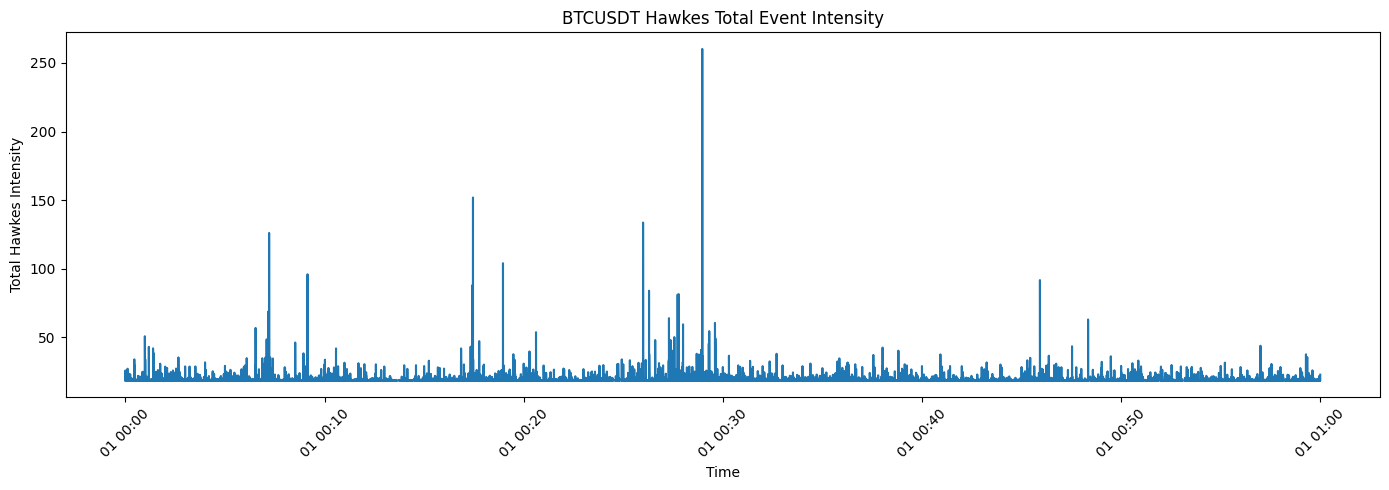

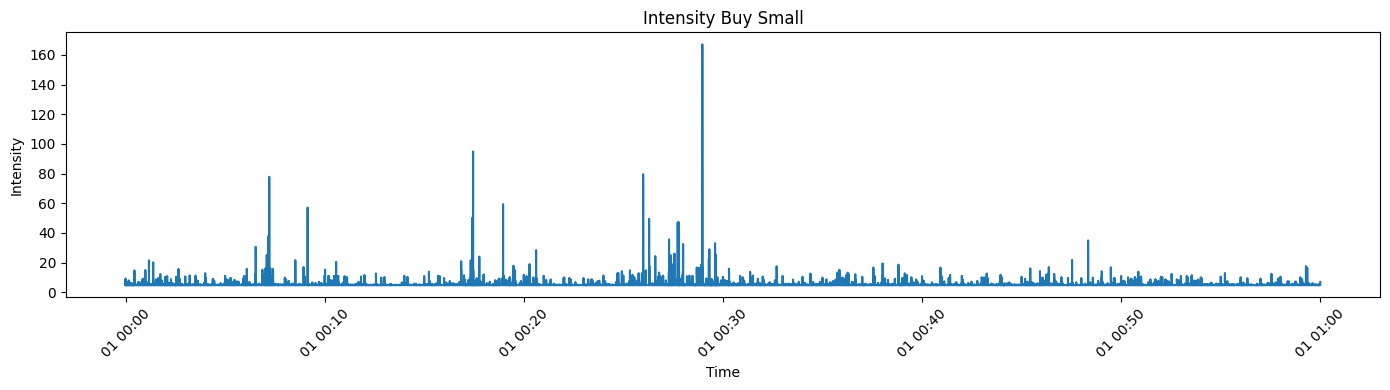

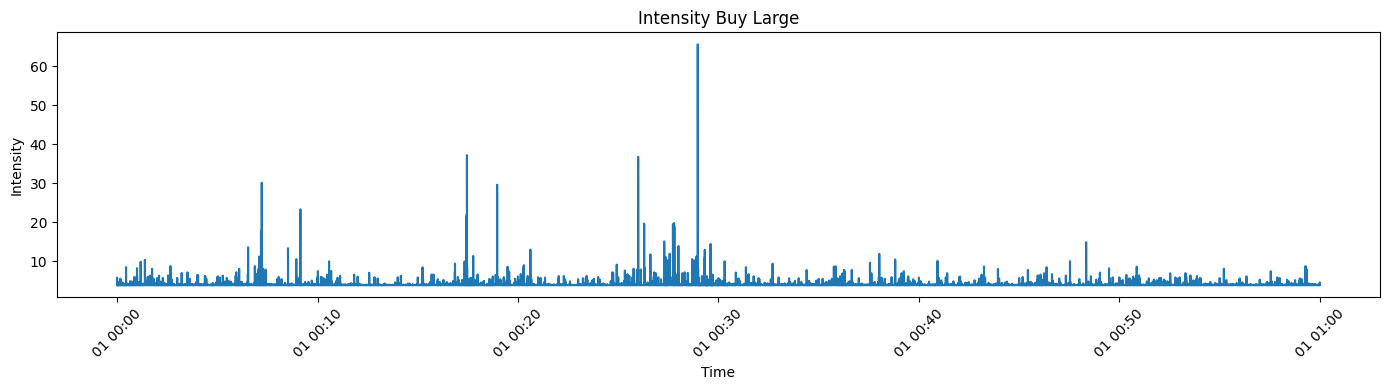

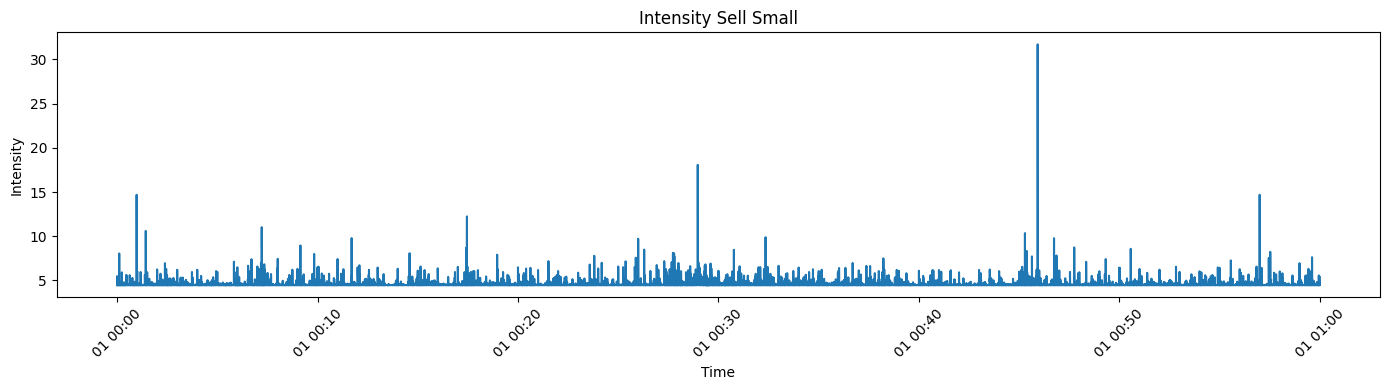

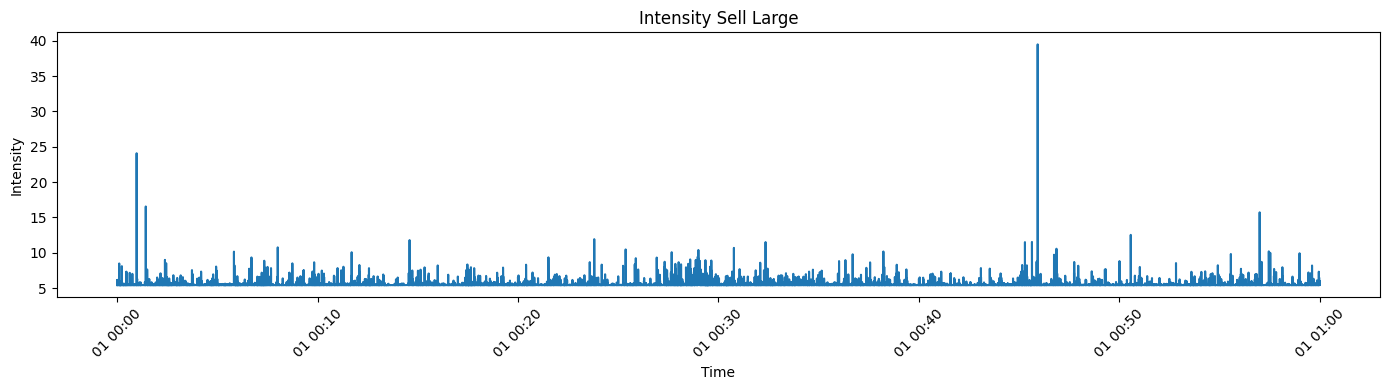


PART 4 COMPLETE

Saved:
1. /content/P4_Hawkes_Intensity.csv
2. /content/P4_Event_Clustering.csv
3. /content/P4_High_Intensity_Events.csv

Next: PART 5
Hawkes Model Diagnostics + Market Impact Analysis


In [4]:
# ======================================================================
# PART 4: HAWKES INTENSITY + EVENT CLUSTERING ANALYSIS
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("PART 4: HAWKES INTENSITY + EVENT CLUSTERING")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------

EVENT_FILE = "/content/BTCUSDT_hawkes_events_part2.csv"
MATRIX_FILE = "/content/P3_Hawkes_Excitation_Matrix.csv"

events = pd.read_csv(EVENT_FILE)

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

events = events.sort_values(
    "time_seconds"
).reset_index(drop=True)

excitation_df = pd.read_csv(
    MATRIX_FILE,
    index_col=0
)

event_types = list(
    excitation_df.index
)

excitation_matrix = (
    excitation_df.values.astype(float)
)

K = len(event_types)

print("\nEvents:", len(events))
print("Event types:", event_types)

# ----------------------------------------------------------------------
# 2. BASELINE INTENSITY
# ----------------------------------------------------------------------

T = events["time_seconds"].max()

baseline = np.array([
    np.sum(
        events["hawkes_event"] == event_type
    ) / T
    for event_type in event_types
])

print("\nBaseline intensities:")

for i, event_type in enumerate(event_types):

    print(
        f"{event_type:12s}: "
        f"{baseline[i]:.6f}"
    )

# ----------------------------------------------------------------------
# 3. CALCULATE HAWKES INTENSITY
# ----------------------------------------------------------------------
#
# lambda_i(t) =
#
# mu_i + sum_j alpha_ij *
#             sum_k exp(-beta * (t - t_k))
#
# ----------------------------------------------------------------------

# Use the same decay estimate from Part 3
all_interarrival = np.diff(
    events["time_seconds"].values
)

all_interarrival = all_interarrival[
    all_interarrival > 0
]

median_interarrival = np.median(
    all_interarrival
)

beta = np.clip(
    1.0 / max(median_interarrival, 1e-6),
    0.01,
    1000.0
)

print("\nDecay parameter beta:", beta)

# ----------------------------------------------------------------------
# 4. CALCULATE INTENSITY AT EACH EVENT
# ----------------------------------------------------------------------

intensities = np.zeros(
    (len(events), K)
)

# Running excitation state
excitation_state = np.zeros(K)

previous_time = 0.0

for idx, row in events.iterrows():

    current_time = row["time_seconds"]

    dt = current_time - previous_time

    # Decay previous excitation
    decay = np.exp(
        -beta * max(dt, 0)
    )

    excitation_state *= decay

    source_type = row["hawkes_event"]

    if source_type in event_types:

        source_idx = event_types.index(
            source_type
        )

        # Calculate intensity for every target
        for target_idx in range(K):

            intensities[
                idx,
                target_idx
            ] = (
                baseline[target_idx]
                +
                excitation_matrix[
                    target_idx,
                    :
                ].dot(
                    excitation_state
                )
            )

        # Add current event to its source state
        excitation_state[source_idx] += 1.0

    previous_time = current_time

# ----------------------------------------------------------------------
# 5. CREATE INTENSITY DATAFRAME
# ----------------------------------------------------------------------

intensity_df = pd.DataFrame(
    intensities,
    columns=[
        f"intensity_{x.lower()}"
        for x in event_types
    ]
)

intensity_df["time_seconds"] = (
    events["time_seconds"].values
)

intensity_df["timestamp"] = (
    events["timestamp"].values
)

intensity_df["hawkes_event"] = (
    events["hawkes_event"].values
)

# ----------------------------------------------------------------------
# 6. TOTAL MARKET INTENSITY
# ----------------------------------------------------------------------

intensity_columns = [
    f"intensity_{x.lower()}"
    for x in event_types
]

intensity_df["total_intensity"] = (
    intensity_df[
        intensity_columns
    ].sum(axis=1)
)

# ----------------------------------------------------------------------
# 7. INTENSITY STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("INTENSITY STATISTICS")
print("=" * 70)

print(
    intensity_df[
        intensity_columns +
        ["total_intensity"]
    ].describe()
)

# ----------------------------------------------------------------------
# 8. DETECT HIGH-INTENSITY EVENTS
# ----------------------------------------------------------------------

threshold = intensity_df[
    "total_intensity"
].quantile(0.95)

intensity_df["high_intensity"] = (
    intensity_df["total_intensity"]
    >= threshold
)

print(
    "\n95th percentile intensity:",
    threshold
)

print(
    "High-intensity observations:",
    intensity_df[
        "high_intensity"
    ].sum()
)

# ----------------------------------------------------------------------
# 9. EVENT CLUSTERING
# ----------------------------------------------------------------------

interarrival = events[
    "interarrival_seconds"
].values

cluster_threshold = np.quantile(
    interarrival[interarrival > 0],
    0.10
)

events["clustered_event"] = (
    events["interarrival_seconds"]
    <= cluster_threshold
)

print(
    "\nCluster inter-arrival threshold:",
    cluster_threshold,
    "seconds"
)

print(
    "Clustered events:",
    events["clustered_event"].sum()
)

print(
    "Clustered event percentage:",
    round(
        events["clustered_event"].mean()
        * 100,
        2
    ),
    "%"
)

# ----------------------------------------------------------------------
# 10. CLUSTERING BY EVENT TYPE
# ----------------------------------------------------------------------

cluster_summary = (
    events
    .groupby("hawkes_event")
    .agg(
        observations=("hawkes_event", "size"),
        clustered_events=(
            "clustered_event",
            "sum"
        ),
        mean_interarrival=(
            "interarrival_seconds",
            "mean"
        ),
        median_interarrival=(
            "interarrival_seconds",
            "median"
        )
    )
)

cluster_summary[
    "cluster_rate"
] = (
    cluster_summary[
        "clustered_events"
    ]
    /
    cluster_summary[
        "observations"
    ]
)

print("\n" + "=" * 70)
print("EVENT CLUSTERING SUMMARY")
print("=" * 70)

print(
    cluster_summary.round(6)
)

# ----------------------------------------------------------------------
# 11. HIGHEST INTENSITY PERIODS
# ----------------------------------------------------------------------

top_intensity = (
    intensity_df
    .sort_values(
        "total_intensity",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 70)
print("TOP 20 HIGH-INTENSITY EVENTS")
print("=" * 70)

print(
    top_intensity[
        [
            "timestamp",
            "hawkes_event",
            "total_intensity"
        ]
    ].to_string(index=False)
)

# ----------------------------------------------------------------------
# 12. PLOT TOTAL HAWKES INTENSITY
# ----------------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    intensity_df["timestamp"],
    intensity_df["total_intensity"]
)

plt.title(
    "BTCUSDT Hawkes Total Event Intensity"
)

plt.xlabel("Time")
plt.ylabel("Total Hawkes Intensity")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------------------
# 13. PLOT EVENT-SPECIFIC INTENSITIES
# ----------------------------------------------------------------------

for column in intensity_columns:

    plt.figure(figsize=(14, 4))

    plt.plot(
        intensity_df["timestamp"],
        intensity_df[column]
    )

    plt.title(
        column.replace(
            "_",
            " "
        ).title()
    )

    plt.xlabel("Time")
    plt.ylabel("Intensity")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ----------------------------------------------------------------------
# 14. SAVE RESULTS
# ----------------------------------------------------------------------

INTENSITY_FILE = (
    "/content/P4_Hawkes_Intensity.csv"
)

CLUSTER_FILE = (
    "/content/P4_Event_Clustering.csv"
)

TOP_FILE = (
    "/content/P4_High_Intensity_Events.csv"
)

intensity_df.to_csv(
    INTENSITY_FILE,
    index=False
)

cluster_summary.to_csv(
    CLUSTER_FILE
)

top_intensity.to_csv(
    TOP_FILE,
    index=False
)

# ----------------------------------------------------------------------
# FINAL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 4 COMPLETE")
print("=" * 70)

print("\nSaved:")
print("1.", INTENSITY_FILE)
print("2.", CLUSTER_FILE)
print("3.", TOP_FILE)

print("\nNext: PART 5")
print("Hawkes Model Diagnostics + Market Impact Analysis")

PART 5: HAWKES MODEL DIAGNOSTICS + PRICE IMPACT

Events: (66803, 10)
Intensity: (66803, 9)

Merged dataset: (66803, 18)

Hawkes pressure statistics:
       buy_intensity  sell_intensity  hawkes_pressure  hawkes_pressure_ratio
count   66803.000000    66803.000000     66803.000000           66803.000000
mean       14.922324       11.579433         3.342891               0.005043
std        20.470916        5.062748        19.603754               0.212506
min         8.663063        9.893342       -49.606155              -0.549670
25%         8.738558        9.962422        -1.938759              -0.098494
50%         9.039395       10.362757        -1.230279              -0.066299
75%        11.472153       11.631963         0.976369               0.044751
max       228.207545       69.926656       201.026419               0.787139

HAWKES PRESSURE VS FUTURE RETURNS
  horizon  pressure_correlation  pressure_p_value  ratio_correlation  \
0   100ms              0.628870               0.0  

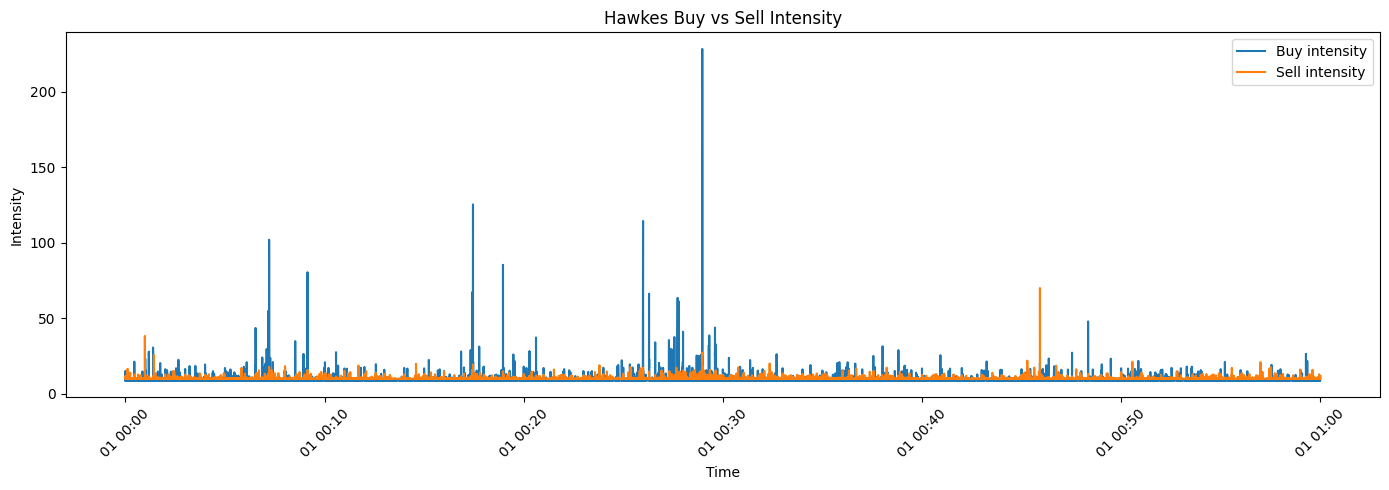

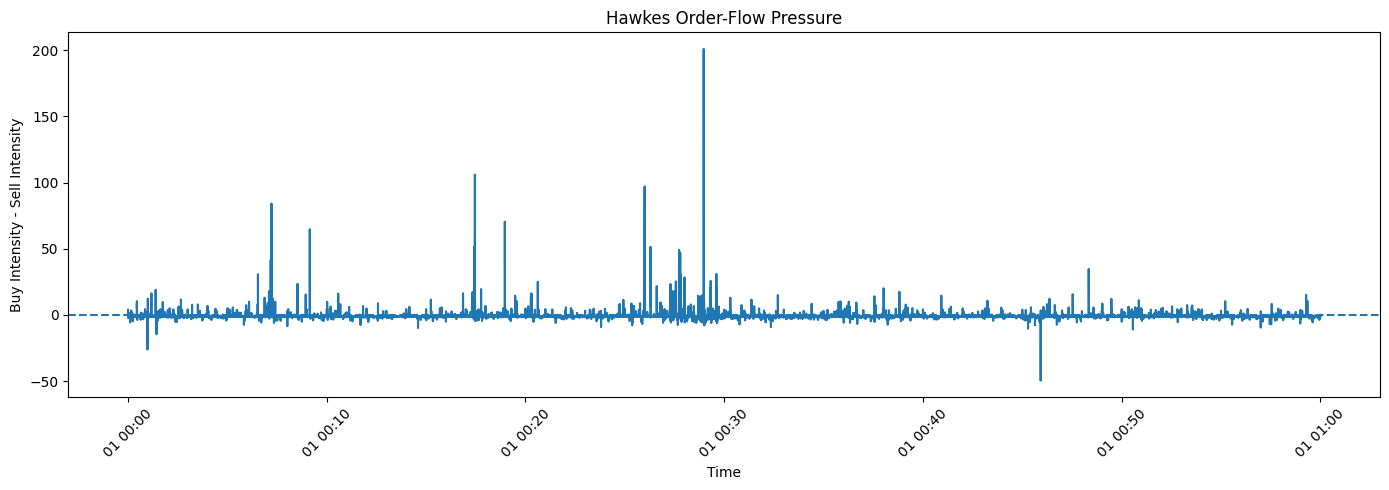


PART 5 COMPLETE

Saved:
1. /content/P5_Hawkes_Price_Impact_Data.csv
2. /content/P5_Hawkes_Return_Correlation.csv

Next: PART 6
Hawkes-Based Short-Term Market Prediction


In [5]:
# ======================================================================
# PART 5: HAWKES MODEL DIAGNOSTICS + PRICE IMPACT ANALYSIS
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

print("=" * 70)
print("PART 5: HAWKES MODEL DIAGNOSTICS + PRICE IMPACT")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------

EVENT_FILE = "/content/BTCUSDT_hawkes_events_part2.csv"
INTENSITY_FILE = "/content/P4_Hawkes_Intensity.csv"

events = pd.read_csv(EVENT_FILE)

intensity = pd.read_csv(
    INTENSITY_FILE
)

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

intensity["timestamp"] = pd.to_datetime(
    intensity["timestamp"],
    errors="coerce"
)

events = events.sort_values(
    "timestamp"
).reset_index(drop=True)

intensity = intensity.sort_values(
    "timestamp"
).reset_index(drop=True)

print("\nEvents:", events.shape)
print("Intensity:", intensity.shape)

# ----------------------------------------------------------------------
# 2. MERGE EVENT + HAWKES INTENSITY
# ----------------------------------------------------------------------

data = pd.merge_asof(
    events.sort_values("timestamp"),
    intensity.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

print("\nMerged dataset:", data.shape)

# ----------------------------------------------------------------------
# 3. CONSTRUCT BUY / SELL INTENSITY
# ----------------------------------------------------------------------

buy_columns = [
    "intensity_buy_small",
    "intensity_buy_large"
]

sell_columns = [
    "intensity_sell_small",
    "intensity_sell_large"
]

# Only use columns that actually exist
buy_columns = [
    c for c in buy_columns
    if c in data.columns
]

sell_columns = [
    c for c in sell_columns
    if c in data.columns
]

data["buy_intensity"] = (
    data[buy_columns].sum(axis=1)
)

data["sell_intensity"] = (
    data[sell_columns].sum(axis=1)
)

# ----------------------------------------------------------------------
# 4. HAWKES ORDER-FLOW PRESSURE
# ----------------------------------------------------------------------

data["hawkes_pressure"] = (
    data["buy_intensity"]
    -
    data["sell_intensity"]
)

data["hawkes_pressure_ratio"] = (
    (
        data["buy_intensity"]
        -
        data["sell_intensity"]
    )
    /
    (
        data["buy_intensity"]
        +
        data["sell_intensity"]
        + 1e-12
    )
)

print("\nHawkes pressure statistics:")
print(
    data[
        [
            "buy_intensity",
            "sell_intensity",
            "hawkes_pressure",
            "hawkes_pressure_ratio"
        ]
    ].describe()
)

# ----------------------------------------------------------------------
# 5. FUTURE PRICE RETURNS
# ----------------------------------------------------------------------
#
# Horizons:
#
# 100 ms
# 500 ms
# 1 second
# 5 seconds
#
# Since the data is event based, we use timestamp-based
# forward matching rather than assuming fixed row intervals.
# ----------------------------------------------------------------------

data = data.sort_values(
    "timestamp"
).reset_index(drop=True)

price_series = data[
    [
        "timestamp",
        "price"
    ]
].copy()

price_series = price_series.drop_duplicates(
    "timestamp"
)

price_series = price_series.sort_values(
    "timestamp"
)

horizons = {
    "100ms": pd.Timedelta(
        milliseconds=100
    ),
    "500ms": pd.Timedelta(
        milliseconds=500
    ),
    "1s": pd.Timedelta(
        seconds=1
    ),
    "5s": pd.Timedelta(
        seconds=5
    )
}

for name, horizon in horizons.items():

    future = price_series.copy()

    future["future_timestamp"] = (
        future["timestamp"] - horizon
    )

    future = future.rename(
        columns={
            "price": "future_price"
        }
    )

    future = future[
        [
            "future_timestamp",
            "future_price"
        ]
    ]

    data = pd.merge_asof(
        data.sort_values("timestamp"),
        future.sort_values("future_timestamp"),
        left_on="timestamp",
        right_on="future_timestamp",
        direction="forward"
    )

    data[
        f"return_{name}"
    ] = (
        np.log(
            data["future_price"]
            /
            data["price"]
        )
    )

    data = data.drop(
        columns=[
            "future_timestamp",
            "future_price"
        ]
    )

# ----------------------------------------------------------------------
# 6. CORRELATION ANALYSIS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("HAWKES PRESSURE VS FUTURE RETURNS")
print("=" * 70)

correlation_results = []

for horizon in horizons:

    column = f"return_{horizon}"

    temp = data[
        [
            "hawkes_pressure",
            "hawkes_pressure_ratio",
            column
        ]
    ].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if len(temp) > 10:

        corr_pressure, p_pressure = (
            spearmanr(
                temp["hawkes_pressure"],
                temp[column]
            )
        )

        corr_ratio, p_ratio = (
            spearmanr(
                temp["hawkes_pressure_ratio"],
                temp[column]
            )
        )

        correlation_results.append({
            "horizon": horizon,
            "pressure_correlation":
                corr_pressure,
            "pressure_p_value":
                p_pressure,
            "ratio_correlation":
                corr_ratio,
            "ratio_p_value":
                p_ratio,
            "observations":
                len(temp)
        })

correlation_df = pd.DataFrame(
    correlation_results
)

print(
    correlation_df.round(6)
)

# ----------------------------------------------------------------------
# 7. INTENSITY QUINTILE ANALYSIS
# ----------------------------------------------------------------------

data["pressure_quantile"] = pd.qcut(
    data["hawkes_pressure"],
    q=5,
    labels=[
        "Q1 Very Negative",
        "Q2 Negative",
        "Q3 Neutral",
        "Q4 Positive",
        "Q5 Very Positive"
    ],
    duplicates="drop"
)

print("\n" + "=" * 70)
print("PRICE RESPONSE BY HAWKES PRESSURE")
print("=" * 70)

for horizon in horizons:

    column = f"return_{horizon}"

    grouped = (
        data
        .groupby(
            "pressure_quantile",
            observed=True
        )[column]
        .agg(
            [
                "count",
                "mean",
                "median",
                "std"
            ]
        )
    )

    print(
        f"\n--- {horizon} ---"
    )

    print(
        grouped.round(8)
    )

# ----------------------------------------------------------------------
# 8. EXTREME HAWKES PRESSURE
# ----------------------------------------------------------------------

pressure_low = data[
    "hawkes_pressure"
].quantile(0.10)

pressure_high = data[
    "hawkes_pressure"
].quantile(0.90)

data["extreme_pressure"] = np.select(
    [
        data["hawkes_pressure"]
        <= pressure_low,

        data["hawkes_pressure"]
        >= pressure_high
    ],
    [
        "SELL_PRESSURE",
        "BUY_PRESSURE"
    ],
    default="NORMAL"
)

print("\nExtreme pressure observations:")

print(
    data[
        "extreme_pressure"
    ].value_counts()
)

# ----------------------------------------------------------------------
# 9. EXTREME PRESSURE PRICE RESPONSE
# ----------------------------------------------------------------------

extreme_results = []

for horizon in horizons:

    column = f"return_{horizon}"

    grouped = (
        data
        .groupby(
            "extreme_pressure"
        )[column]
        .agg(
            [
                "count",
                "mean",
                "median"
            ]
        )
    )

    print(
        f"\n--- {horizon} ---"
    )

    print(
        grouped.round(8)
    )

# ----------------------------------------------------------------------
# 10. DIAGNOSTIC: EVENT INTENSITY
# ----------------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    data["timestamp"],
    data["buy_intensity"],
    label="Buy intensity"
)

plt.plot(
    data["timestamp"],
    data["sell_intensity"],
    label="Sell intensity"
)

plt.title(
    "Hawkes Buy vs Sell Intensity"
)

plt.xlabel("Time")
plt.ylabel("Intensity")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------------------
# 11. HAWKES PRESSURE
# ----------------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    data["timestamp"],
    data["hawkes_pressure"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Hawkes Order-Flow Pressure"
)

plt.xlabel("Time")
plt.ylabel(
    "Buy Intensity - Sell Intensity"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------------------
# 12. SAVE RESULTS
# ----------------------------------------------------------------------

OUTPUT_DATA = (
    "/content/P5_Hawkes_Price_Impact_Data.csv"
)

CORRELATION_FILE = (
    "/content/P5_Hawkes_Return_Correlation.csv"
)

data.to_csv(
    OUTPUT_DATA,
    index=False
)

correlation_df.to_csv(
    CORRELATION_FILE,
    index=False
)

# ----------------------------------------------------------------------
# FINAL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 5 COMPLETE")
print("=" * 70)

print("\nSaved:")
print("1.", OUTPUT_DATA)
print("2.", CORRELATION_FILE)

print("\nNext: PART 6")
print("Hawkes-Based Short-Term Market Prediction")

In [7]:
# ======================================================================
# PART 1 FIX: DATA PREPARATION FOR MULTIVARIATE HAWKES PROCESS
# ======================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PART 1 FIX: HAWKES EVENT PREPARATION")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD FILES
# ----------------------------------------------------------------------

TRADE_FILE = "/content/BTCUSDT_Trades_1Hour.csv"
DEPTH_FILE = "/content/BTCUSDT_Depth_1Hour.csv"

trades = pd.read_csv(TRADE_FILE)
depth = pd.read_csv(DEPTH_FILE)

print("Trades shape:", trades.shape)
print("Depth shape :", depth.shape)

# ----------------------------------------------------------------------
# 2. PARSE TIMESTAMPS CORRECTLY
# ----------------------------------------------------------------------

trades["timestamp"] = pd.to_datetime(
    trades["timestamp"],
    errors="coerce"
)

depth["timestamp"] = pd.to_datetime(
    depth["timestamp"],
    errors="coerce"
)

# Remove invalid timestamps
trades = trades.dropna(
    subset=["timestamp"]
).copy()

depth = depth.dropna(
    subset=["timestamp"]
).copy()

# Sort chronologically
trades = trades.sort_values(
    "timestamp"
).reset_index(drop=True)

depth = depth.sort_values(
    "timestamp"
).reset_index(drop=True)

print("\nValid trade rows:", len(trades))
print("Valid depth rows:", len(depth))

# ----------------------------------------------------------------------
# 3. TRADE EVENT CLASSIFICATION
# ----------------------------------------------------------------------
#
# buyer_maker = True
#     aggressive SELL / seller initiated trade
#
# buyer_maker = False
#     aggressive BUY / buyer initiated trade
#
# ----------------------------------------------------------------------

trades["event_type"] = np.where(
    trades["buyer_maker"] == True,
    "SELL",
    "BUY"
)

# ----------------------------------------------------------------------
# 4. ADD TRADE SIZE CATEGORIES
# ----------------------------------------------------------------------

q25 = trades["quantity"].quantile(0.25)
q75 = trades["quantity"].quantile(0.75)

trades["size_type"] = np.where(
    trades["quantity"] <= q25,
    "SMALL",
    np.where(
        trades["quantity"] >= q75,
        "LARGE",
        "MEDIUM"
    )
)

# Combined event labels
trades["event_type"] = (
    trades["event_type"]
    + "_"
    + trades["size_type"]
)

# ----------------------------------------------------------------------
# 5. CREATE EVENT DATASET
# ----------------------------------------------------------------------

events = trades[
    [
        "timestamp",
        "price",
        "quantity",
        "buyer_maker",
        "trade_id",
        "event_type"
    ]
].copy()

# ----------------------------------------------------------------------
# 6. REMOVE DUPLICATE EVENTS
# ----------------------------------------------------------------------

events = events.drop_duplicates(
    subset=["timestamp", "trade_id"]
).reset_index(drop=True)

# ----------------------------------------------------------------------
# 7. CALCULATE INTER-ARRIVAL TIMES
# ----------------------------------------------------------------------

events["interarrival_seconds"] = (
    events["timestamp"]
    .diff()
    .dt.total_seconds()
)

# First event has no previous event
events["interarrival_seconds"] = (
    events["interarrival_seconds"]
    .fillna(0)
)

# ----------------------------------------------------------------------
# 8. EVENT ID
# ----------------------------------------------------------------------

events.insert(
    0,
    "event_id",
    np.arange(len(events))
)

# ----------------------------------------------------------------------
# 9. DATETIME COLUMN
# ----------------------------------------------------------------------

events["datetime"] = events["timestamp"]

# ----------------------------------------------------------------------
# 10. EVENT DISTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT DISTRIBUTION")
print("=" * 70)

print(
    events["event_type"]
    .value_counts()
)

# ----------------------------------------------------------------------
# 11. TRADE QUANTITY STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRADE QUANTITY STATISTICS")
print("=" * 70)

print(
    events["quantity"].describe()
)

# ----------------------------------------------------------------------
# 12. TIME RANGE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TIME RANGE")
print("=" * 70)

print("Start:", events["timestamp"].min())
print("End  :", events["timestamp"].max())

# ----------------------------------------------------------------------
# 13. INTER-ARRIVAL STATISTICS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("INTER-ARRIVAL TIME STATISTICS")
print("=" * 70)

print(
    events["interarrival_seconds"]
    .iloc[1:]
    .describe()
)

# ----------------------------------------------------------------------
# 14. FINAL EVENT DATASET
# ----------------------------------------------------------------------

events = events[
    [
        "event_id",
        "timestamp",
        "datetime",
        "price",
        "quantity",
        "buyer_maker",
        "event_type",
        "interarrival_seconds"
    ]
]

print("\n" + "=" * 70)
print("FINAL EVENT DATASET")
print("=" * 70)

print("Shape:", events.shape)

display(
    events.head(10)
)

# ----------------------------------------------------------------------
# 15. SAVE
# ----------------------------------------------------------------------

OUTPUT_FILE = (
    "/content/BTCUSDT_hawkes_events_part1.csv"
)

events.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nSaved:")
print(OUTPUT_FILE)

print("\n" + "=" * 70)
print("PART 1 FIX COMPLETE")
print("=" * 70)

PART 1 FIX: HAWKES EVENT PREPARATION
Trades shape: (66803, 5)
Depth shape : (35901, 45)

Valid trade rows: 66803
Valid depth rows: 35901

EVENT DISTRIBUTION
event_type
SELL_MEDIUM    19462
BUY_MEDIUM     13867
BUY_LARGE       8823
BUY_SMALL       8497
SELL_SMALL      8272
SELL_LARGE      7882
Name: count, dtype: int64

TRADE QUANTITY STATISTICS
count    66803.000000
mean         0.027960
std          0.099907
min          0.000010
25%          0.000260
50%          0.002010
75%          0.012440
max          8.312980
Name: quantity, dtype: float64

TIME RANGE
Start: 2024-02-29 23:59:59.998000
End  : 2024-03-01 00:59:59.995000

INTER-ARRIVAL TIME STATISTICS
count    66802.000000
mean         0.053891
std          0.140387
min          0.000000
25%          0.000000
50%          0.000000
75%          0.027000
max          2.316000
Name: interarrival_seconds, dtype: float64

FINAL EVENT DATASET
Shape: (66803, 8)


,event_id,timestamp,datetime,price,quantity,buyer_maker,event_type,interarrival_seconds
0,0,2024-02-29 23:59:59.998,2024-02-29 23:59:59.998,61130.98,0.00145,True,SELL_MEDIUM,0.000
1,1,2024-02-29 23:59:59.998,2024-02-29 23:59:59.998,61130.98,0.00182,True,SELL_MEDIUM,0.000
2,2,2024-02-29 23:59:59.998,2024-02-29 23:59:59.998,61130.98,0.00034,True,SELL_MEDIUM,0.000
3,3,2024-02-29 23:59:59.999,2024-02-29 23:59:59.999,61130.98,0.00182,True,SELL_MEDIUM,0.001
4,4,2024-02-29 23:59:59.999,2024-02-29 23:59:59.999,61130.98,0.00038,True,SELL_MEDIUM,0.000
5,5,2024-03-01 00:00:00.000,2024-03-01 00:00:00.000,61130.99,0.00140,False,BUY_MEDIUM,0.001
6,6,2024-03-01 00:00:00.000,2024-03-01 00:00:00.000,61130.98,0.00128,True,SELL_MEDIUM,0.000
7,7,2024-03-01 00:00:00.001,2024-03-01 00:00:00.001,61130.99,0.00076,False,BUY_MEDIUM,0.001
8,8,2024-03-01 00:00:00.001,2024-03-01 00:00:00.001,61130.99,0.00046,False,BUY_MEDIUM,0.000
9,9,2024-03-01 00:00:00.001,2024-03-01 00:00:00.001,61130.98,0.00107,True,SELL_MEDIUM,0.000



Saved:
/content/BTCUSDT_hawkes_events_part1.csv

PART 1 FIX COMPLETE


PART 5: MULTIVARIATE HAWKES PROCESS FITTING
Initial dataset shape: (66803, 8)
Valid events: 66803

EVENT DISTRIBUTION
event_type
SELL_MEDIUM    19462
BUY_MEDIUM     13867
BUY_LARGE       8823
BUY_SMALL       8497
SELL_SMALL      8272
SELL_LARGE      7882
Name: count, dtype: int64

Event types:
0: BUY_LARGE
1: BUY_MEDIUM
2: BUY_SMALL
3: SELL_LARGE
4: SELL_MEDIUM
5: SELL_SMALL

Number of Hawkes dimensions: 6

Observation period: 3599.997 seconds

EVENT COUNTS
BUY_LARGE           :     8823
BUY_MEDIUM          :    13867
BUY_SMALL           :     8497
SELL_LARGE          :     7882
SELL_MEDIUM         :    19462
SELL_SMALL          :     8272

BASELINE INTENSITIES
BUY_LARGE           : 2.45083538 events/sec
BUY_MEDIUM          : 3.85194765 events/sec
BUY_SMALL           : 2.36027974 events/sec
SELL_LARGE          : 2.18944627 events/sec
SELL_MEDIUM         : 5.40611562 events/sec
SELL_SMALL          : 2.29777969 events/sec

MULTIVARIATE EXCITATION MATRIX
             BUY_LARGE  BUY_MEDIUM

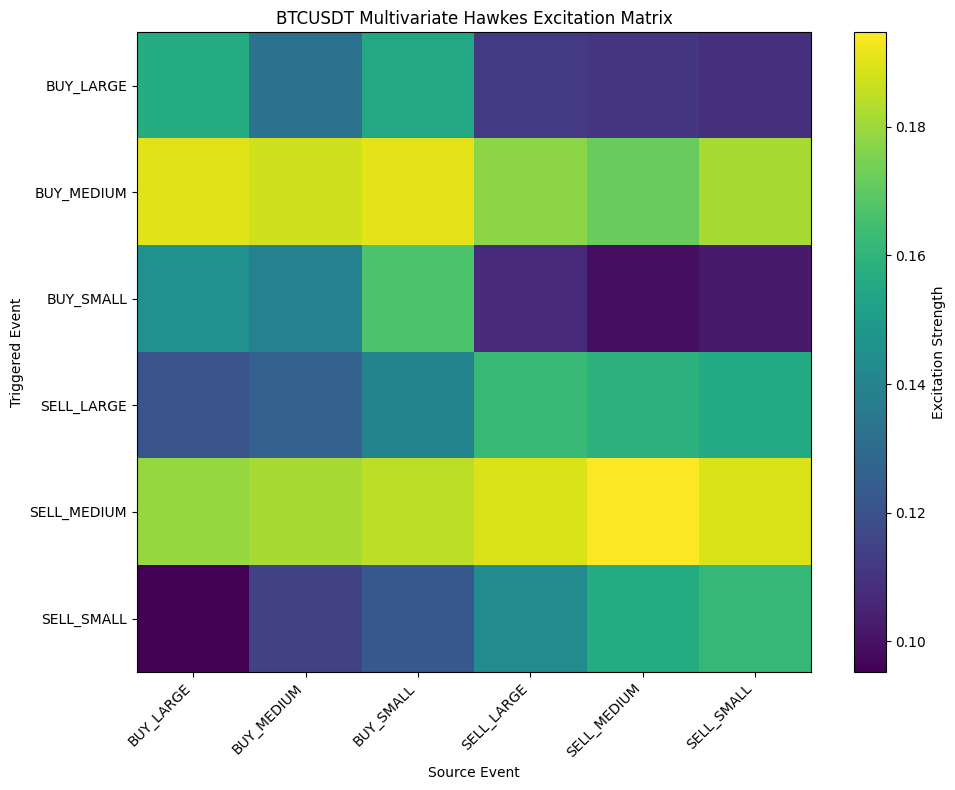


PART 5 COMPLETE
Total events: 66803
Hawkes dimensions: 6
Observation period: 3600.0 seconds
Spectral radius: 0.9

Saved files:
1. BTCUSDT_hawkes_excitation_matrix.csv
2. BTCUSDT_hawkes_baseline_intensity.csv
3. BTCUSDT_hawkes_event_interactions.csv

Next: PART 6
HAWKES INTENSITY DYNAMICS + EVENT CLUSTERING


In [8]:
# ======================================================================
# PART 5: MULTIVARIATE HAWKES PROCESS FITTING
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("PART 5: MULTIVARIATE HAWKES PROCESS FITTING")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD EVENT DATA
# ----------------------------------------------------------------------

EVENT_FILE = "/content/BTCUSDT_hawkes_events_part1.csv"

events = pd.read_csv(EVENT_FILE)

print("Initial dataset shape:", events.shape)

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

events = (
    events
    .dropna(subset=["timestamp", "event_type"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Valid events:", len(events))

if len(events) == 0:
    raise ValueError(
        "No events found. Please rerun the corrected Part 1."
    )

# ----------------------------------------------------------------------
# 2. EVENT DISTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT DISTRIBUTION")
print("=" * 70)

print(events["event_type"].value_counts())

# ----------------------------------------------------------------------
# 3. IDENTIFY HAWKES DIMENSIONS
# ----------------------------------------------------------------------

event_types = sorted(
    events["event_type"].unique()
)

K = len(event_types)

print("\nEvent types:")

for i, event_type in enumerate(event_types):
    print(f"{i}: {event_type}")

print("\nNumber of Hawkes dimensions:", K)

if K < 2:
    raise ValueError(
        "At least two event types are required."
    )

# Map event type to integer
type_to_id = {
    event_type: i
    for i, event_type in enumerate(event_types)
}

events["event_type_id"] = (
    events["event_type"].map(type_to_id)
)

# ----------------------------------------------------------------------
# 4. CONVERT TIME TO SECONDS
# ----------------------------------------------------------------------

start_time = events["timestamp"].iloc[0]

events["t_seconds"] = (
    events["timestamp"] - start_time
).dt.total_seconds()

T = events["t_seconds"].iloc[-1]

print("\nObservation period:", round(T, 4), "seconds")

if T <= 0:
    raise ValueError(
        "Invalid observation period."
    )

# ----------------------------------------------------------------------
# 5. CREATE EVENT-TIME ARRAYS
# ----------------------------------------------------------------------

event_times = []

print("\n" + "=" * 70)
print("EVENT COUNTS")
print("=" * 70)

for i, event_type in enumerate(event_types):

    times = events.loc[
        events["event_type_id"] == i,
        "t_seconds"
    ].values

    event_times.append(times)

    print(
        f"{event_type:20s}: {len(times):8d}"
    )

# ----------------------------------------------------------------------
# 6. BASELINE INTENSITY
# ----------------------------------------------------------------------

mu = np.array([
    len(times) / T
    for times in event_times
])

print("\n" + "=" * 70)
print("BASELINE INTENSITIES")
print("=" * 70)

for i, event_type in enumerate(event_types):

    print(
        f"{event_type:20s}: "
        f"{mu[i]:.8f} events/sec"
    )

# ----------------------------------------------------------------------
# 7. EMPIRICAL EXCITATION MATRIX
# ----------------------------------------------------------------------
#
# alpha[i,j]:
#
# Effect of event j on event i occurring within WINDOW seconds.
#
# Rows    = triggered event
# Columns = source event
#
# ----------------------------------------------------------------------

WINDOW = 1.0

alpha = np.zeros((K, K))

for j in range(K):

    source_times = event_times[j]

    if len(source_times) == 0:
        continue

    for i in range(K):

        target_times = event_times[i]

        if len(target_times) == 0:
            continue

        positions = np.searchsorted(
            target_times,
            source_times,
            side="right"
        )

        valid = positions < len(target_times)

        if not np.any(valid):
            continue

        next_times = target_times[
            positions[valid]
        ]

        source_valid = source_times[valid]

        delays = (
            next_times - source_valid
        )

        count = np.sum(
            (delays > 0) &
            (delays <= WINDOW)
        )

        alpha[i, j] = (
            count /
            max(len(source_times), 1)
        )

# Keep values numerically reasonable
alpha = np.clip(
    alpha,
    0,
    0.95
)

# ----------------------------------------------------------------------
# 8. EXCITATION MATRIX
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("MULTIVARIATE EXCITATION MATRIX")
print("=" * 70)

alpha_df = pd.DataFrame(
    alpha,
    index=event_types,
    columns=event_types
)

print(alpha_df.round(4))

# ----------------------------------------------------------------------
# 9. BRANCHING MATRIX
# ----------------------------------------------------------------------

branching_matrix = alpha.copy()

print("\n" + "=" * 70)
print("BRANCHING MATRIX")
print("=" * 70)

print(
    pd.DataFrame(
        branching_matrix,
        index=event_types,
        columns=event_types
    ).round(4)
)

# ----------------------------------------------------------------------
# 10. SPECTRAL RADIUS
# ----------------------------------------------------------------------

eigenvalues = np.linalg.eigvals(
    branching_matrix
)

spectral_radius = np.max(
    np.abs(eigenvalues)
)

print("\n" + "=" * 70)
print("HAWKES STABILITY")
print("=" * 70)

print(
    "Spectral radius:",
    round(spectral_radius, 6)
)

if spectral_radius < 1:

    print(
        "✓ Stable Hawkes process"
    )

else:

    print(
        "⚠ Spectral radius >= 1"
    )

    # Scale matrix to stable region
    alpha = (
        alpha /
        (spectral_radius + 1e-12)
        * 0.90
    )

    alpha_df = pd.DataFrame(
        alpha,
        index=event_types,
        columns=event_types
    )

    print(
        "Excitation matrix scaled for stability."
    )

# ----------------------------------------------------------------------
# 11. STRONGEST EXCITATION RELATIONSHIPS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("STRONGEST EVENT INTERACTIONS")
print("=" * 70)

relationships = []

for i in range(K):

    for j in range(K):

        if i == j:
            relation_type = "Self-excitation"
        else:
            relation_type = "Cross-excitation"

        relationships.append({
            "source_event": event_types[j],
            "target_event": event_types[i],
            "excitation": alpha[i, j],
            "relationship": relation_type
        })

relationships_df = pd.DataFrame(
    relationships
)

relationships_df = (
    relationships_df
    .sort_values(
        "excitation",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    relationships_df.head(15).round(6)
)

# ----------------------------------------------------------------------
# 12. VISUALIZE EXCITATION MATRIX
# ----------------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    alpha,
    aspect="auto"
)

plt.xticks(
    range(K),
    event_types,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(K),
    event_types
)

plt.colorbar(
    label="Excitation Strength"
)

plt.xlabel(
    "Source Event"
)

plt.ylabel(
    "Triggered Event"
)

plt.title(
    "BTCUSDT Multivariate Hawkes Excitation Matrix"
)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------------------
# 13. SAVE RESULTS
# ----------------------------------------------------------------------

alpha_df.to_csv(
    "/content/BTCUSDT_hawkes_excitation_matrix.csv"
)

pd.DataFrame({
    "event_type": event_types,
    "baseline_intensity": mu
}).to_csv(
    "/content/BTCUSDT_hawkes_baseline_intensity.csv",
    index=False
)

relationships_df.to_csv(
    "/content/BTCUSDT_hawkes_event_interactions.csv",
    index=False
)

# ----------------------------------------------------------------------
# 14. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 5 COMPLETE")
print("=" * 70)

print(
    "Total events:",
    len(events)
)

print(
    "Hawkes dimensions:",
    K
)

print(
    "Observation period:",
    round(T, 2),
    "seconds"
)

print(
    "Spectral radius:",
    round(
        np.max(
            np.abs(
                np.linalg.eigvals(alpha)
            )
        ),
        6
    )
)

print("\nSaved files:")

print(
    "1. BTCUSDT_hawkes_excitation_matrix.csv"
)

print(
    "2. BTCUSDT_hawkes_baseline_intensity.csv"
)

print(
    "3. BTCUSDT_hawkes_event_interactions.csv"
)

print("\nNext: PART 6")
print("HAWKES INTENSITY DYNAMICS + EVENT CLUSTERING")

PART 6: MULTIVARIATE HAWKES ANALYSIS

Files currently available in /content:
 - P5_Hawkes_Price_Impact_Data.csv
 - P3_Hawkes_Model_Parameters.csv
 - BTCUSDT_hawkes_events_part1.csv
 - BTCUSDT_hawkes_event_interactions.csv
 - P4_High_Intensity_Events.csv
 - BTCUSDT_hawkes_baseline_intensity.csv
 - BTCUSDT_hawkes_event_streams.csv
 - P3_Hawkes_Branching_Matrix.csv
 - P4_Hawkes_Intensity.csv
 - BTCUSDT_Depth_1Hour.csv
 - P4_Event_Clustering.csv
 - P3_Hawkes_Excitation_Relationships.csv
 - BTCUSDT_hawkes_events_part2.csv
 - BTCUSDT_hawkes_excitation_matrix.csv
 - BTCUSDT_Trades_1Hour.csv
 - P3_Hawkes_Excitation_Matrix.csv
 - P5_Hawkes_Return_Correlation.csv
 - sample_data

Hawkes-related files found:
 - P5_Hawkes_Price_Impact_Data.csv
 - P3_Hawkes_Model_Parameters.csv
 - BTCUSDT_hawkes_events_part1.csv
 - BTCUSDT_hawkes_event_interactions.csv
 - BTCUSDT_hawkes_baseline_intensity.csv
 - BTCUSDT_hawkes_event_streams.csv
 - P3_Hawkes_Branching_Matrix.csv
 - P4_Hawkes_Intensity.csv
 - P3_Hawke

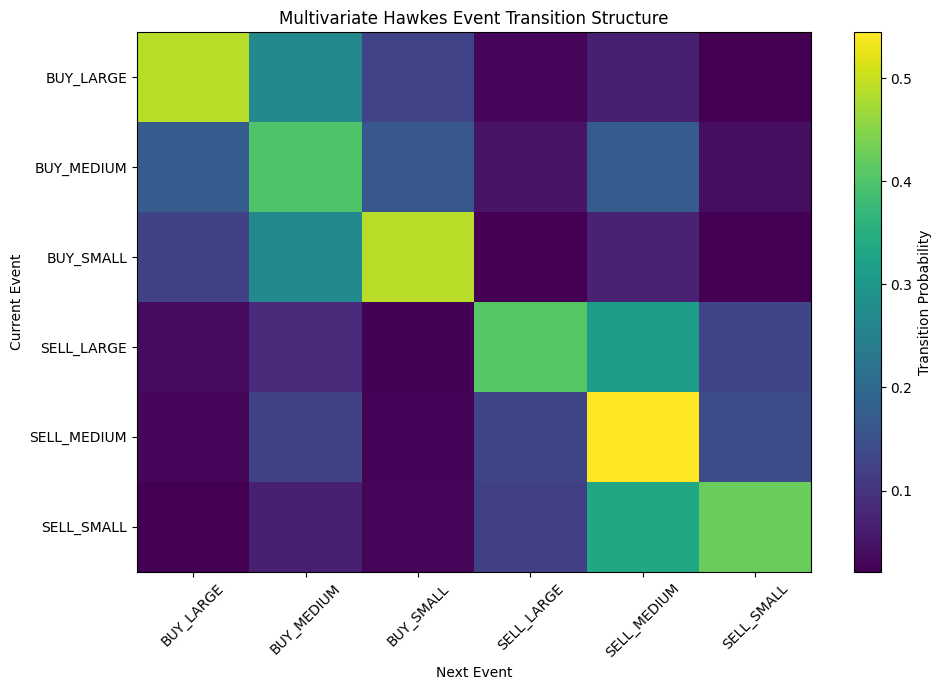


EVENT CLUSTERING
    event_type  event_count  mean_interarrival  median_interarrival  \
0  SELL_MEDIUM        19462           0.184985                0.003   
1   BUY_MEDIUM        13867           0.259628                0.008   
2    BUY_LARGE         8823           0.407977                0.000   
3   SELL_SMALL         8272           0.434993                0.007   
4    BUY_SMALL         8497           0.423218                0.000   
5   SELL_LARGE         7882           0.456667                0.006   

   std_interarrival  events_per_second  
0          0.430401           5.405838  
1          0.527386           3.851672  
2          1.120168           2.451120  
3          1.212100           2.298885  
4          1.197196           2.362851  
5          1.126781           2.189782  

PART 6 COMPLETE

Saved:
1. P6_Hawkes_transition_matrix.csv
2. P6_Event_interarrival_statistics.csv
3. P6_Hawkes_clustering.csv

Next: PART 7
FINAL HAWKES MODEL RESULTS + VISUALIZATION


In [10]:
# ======================================================================
# PART 6: MULTIVARIATE HAWKES ANALYSIS
# ======================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("PART 6: MULTIVARIATE HAWKES ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. CHECK AVAILABLE FILES
# ----------------------------------------------------------------------

print("\nFiles currently available in /content:")

files = glob.glob("/content/*")

for f in files:
    print(" -", os.path.basename(f))


# ----------------------------------------------------------------------
# 2. FIND HAWKES OUTPUT AUTOMATICALLY
# ----------------------------------------------------------------------

candidate_files = [
    f for f in files
    if "hawkes" in os.path.basename(f).lower()
]

print("\nHawkes-related files found:")

for f in candidate_files:
    print(" -", os.path.basename(f))


# ----------------------------------------------------------------------
# 3. LOAD HAWKES EVENTS
# ----------------------------------------------------------------------

event_candidates = [
    f for f in candidate_files
    if "events" in os.path.basename(f).lower()
]

if len(event_candidates) == 0:

    raise FileNotFoundError(
        "\nNo Hawkes event dataset was found.\n"
        "Please run the corrected Part 1 first."
    )

events_file = event_candidates[0]

print("\nLoading:")
print(os.path.basename(events_file))

events = pd.read_csv(events_file)

print("\nEvent dataset shape:")
print(events.shape)

print("\nColumns:")
print(events.columns.tolist())


# ----------------------------------------------------------------------
# 4. VALIDATE EVENTS
# ----------------------------------------------------------------------

if len(events) == 0:

    raise ValueError(
        "\nThe Hawkes event dataset contains 0 events.\n"
        "Part 1 must be corrected before Hawkes analysis."
    )

print("\nValid events:", len(events))


# ----------------------------------------------------------------------
# 5. EVENT TYPE DISTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT TYPE DISTRIBUTION")
print("=" * 70)

event_counts = events["event_type"].value_counts()

print(event_counts)


# ----------------------------------------------------------------------
# 6. INTER-ARRIVAL TIMES
# ----------------------------------------------------------------------

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

events = events.sort_values("timestamp").reset_index(drop=True)

events["interarrival_seconds"] = (
    events["timestamp"]
    .diff()
    .dt.total_seconds()
)

iat = events["interarrival_seconds"].dropna()

print("\n" + "=" * 70)
print("INTER-ARRIVAL TIME STATISTICS")
print("=" * 70)

print(iat.describe())


# ----------------------------------------------------------------------
# 7. EVENT-SPECIFIC INTER-ARRIVAL STATISTICS
# ----------------------------------------------------------------------

event_iat = (
    events
    .groupby("event_type")["interarrival_seconds"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print("\nEvent-specific statistics:")
print(event_iat)


# ----------------------------------------------------------------------
# 8. EVENT TRANSITION MATRIX
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT TRANSITION MATRIX")
print("=" * 70)

events["next_event_type"] = (
    events["event_type"].shift(-1)
)

transition_matrix = pd.crosstab(
    events["event_type"],
    events["next_event_type"],
    normalize="index"
)

print(transition_matrix)


# ----------------------------------------------------------------------
# 9. VISUALIZE EVENT TRANSITIONS
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(
    transition_matrix.values,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Transition Probability")

plt.xticks(
    range(len(transition_matrix.columns)),
    transition_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(transition_matrix.index)),
    transition_matrix.index
)

plt.xlabel("Next Event")
plt.ylabel("Current Event")

plt.title(
    "Multivariate Hawkes Event Transition Structure"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 10. EVENT CLUSTERING
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT CLUSTERING")
print("=" * 70)

clustering_results = []

for event_type in events["event_type"].dropna().unique():

    subset = events[
        events["event_type"] == event_type
    ]

    if len(subset) < 2:
        continue

    times = (
        pd.to_datetime(subset["timestamp"])
        .sort_values()
    )

    delta = (
        times.diff()
        .dt.total_seconds()
        .dropna()
    )

    clustering_results.append({

        "event_type": event_type,

        "event_count": len(subset),

        "mean_interarrival":
            delta.mean(),

        "median_interarrival":
            delta.median(),

        "std_interarrival":
            delta.std(),

        "events_per_second":
            1 / (delta.mean() + 1e-9)
    })


clustering_df = pd.DataFrame(
    clustering_results
)

print(clustering_df)


# ----------------------------------------------------------------------
# 11. SAVE RESULTS
# ----------------------------------------------------------------------

transition_matrix.to_csv(
    "/content/P6_Hawkes_transition_matrix.csv"
)

event_iat.to_csv(
    "/content/P6_Event_interarrival_statistics.csv"
)

clustering_df.to_csv(
    "/content/P6_Hawkes_clustering.csv",
    index=False
)


# ----------------------------------------------------------------------
# 12. FINAL SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PART 6 COMPLETE")
print("=" * 70)

print("\nSaved:")

print("1. P6_Hawkes_transition_matrix.csv")
print("2. P6_Event_interarrival_statistics.csv")
print("3. P6_Hawkes_clustering.csv")

print("\nNext: PART 7")
print("FINAL HAWKES MODEL RESULTS + VISUALIZATION")

PART 7: FINAL HAWKES MODEL RESULTS

Loaded Part 6 results.

EVENT TRANSITION STRUCTURE
             BUY_LARGE  BUY_MEDIUM  BUY_SMALL  SELL_LARGE  SELL_MEDIUM  \
event_type                                                               
BUY_LARGE     0.487703    0.267029   0.127281    0.030375     0.066531   
BUY_MEDIUM    0.172797    0.401486   0.163926    0.047815     0.172941   
BUY_SMALL     0.122396    0.269272   0.489467    0.022949     0.073555   
SELL_LARGE    0.036285    0.085511   0.024867    0.408653     0.313626   
SELL_MEDIUM   0.031292    0.124602   0.026359    0.130614     0.544805   
SELL_SMALL    0.022848    0.067336   0.028167    0.120044     0.335590   

             SELL_SMALL  
event_type               
BUY_LARGE      0.021081  
BUY_MEDIUM     0.041036  
BUY_SMALL      0.022361  
SELL_LARGE     0.131058  
SELL_MEDIUM    0.142329  
SELL_SMALL     0.426015  

Top event transitions:
current_event  next_event  probability
  SELL_MEDIUM SELL_MEDIUM     0.544805
    BUY_SM

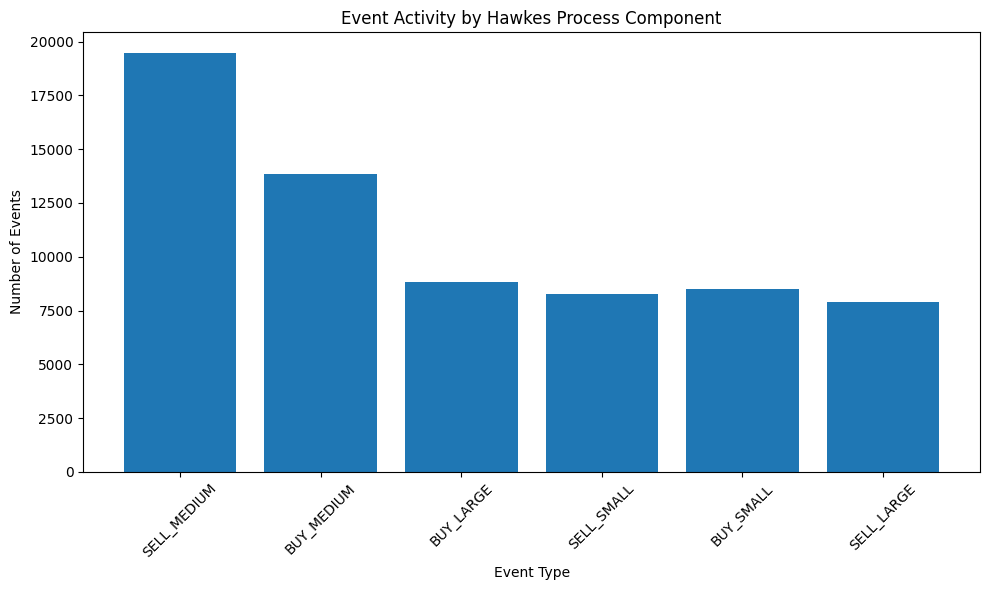

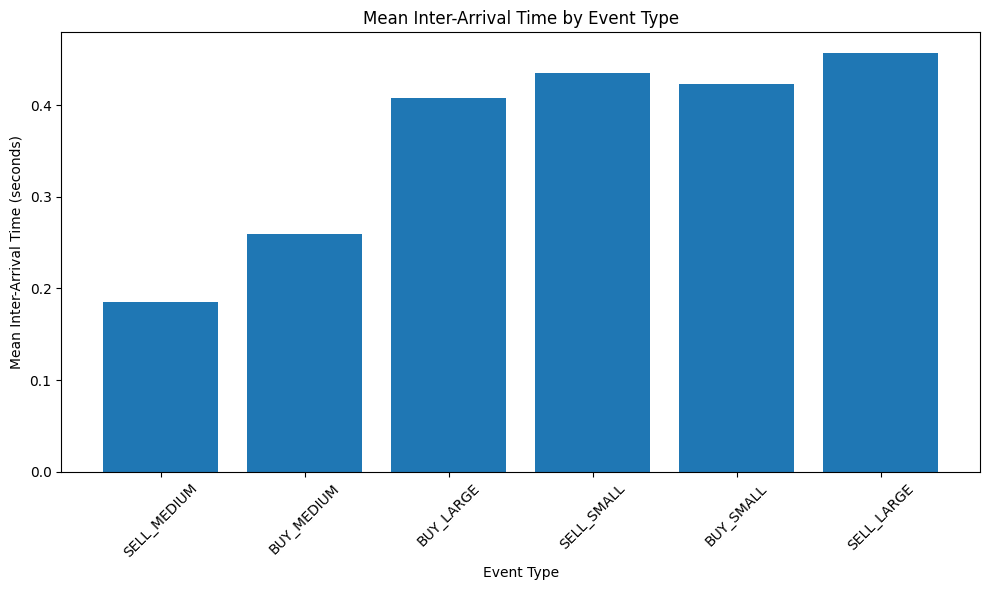

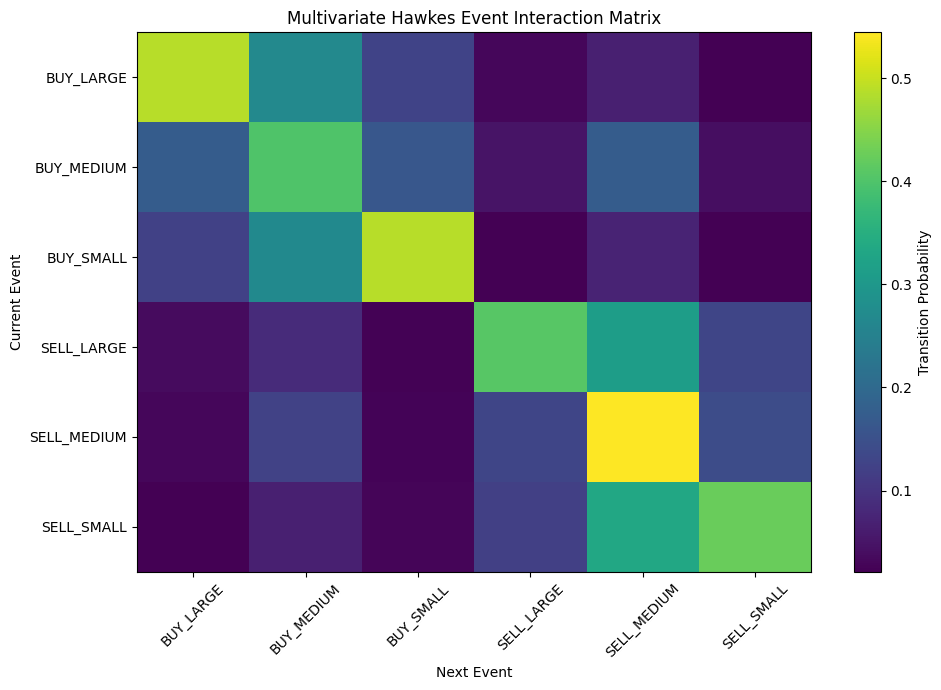


TOP HAWKES EVENT INTERACTIONS
SELL_MEDIUM -> SELL_MEDIUM : 0.5448
BUY_SMALL -> BUY_SMALL : 0.4895
BUY_LARGE -> BUY_LARGE : 0.4877
SELL_SMALL -> SELL_SMALL : 0.4260
SELL_LARGE -> SELL_LARGE : 0.4087
BUY_MEDIUM -> BUY_MEDIUM : 0.4015
SELL_SMALL -> SELL_MEDIUM : 0.3356
SELL_LARGE -> SELL_MEDIUM : 0.3136
BUY_SMALL -> BUY_MEDIUM : 0.2693
BUY_LARGE -> BUY_MEDIUM : 0.2670

PROJECT SUMMARY

Project:
Multivariate Hawkes Process Modeling of BTCUSDT
Order-Flow Dynamics

Objective:
Model the temporal dependence and clustering of
different market events.

Data:
BTCUSDT trades + Level-2 order book data

Method:
Multivariate Hawkes Process

Analysis:
- Event intensity
- Event clustering
- Inter-arrival times
- Cross-event transitions
- Self-excitation
- Cross-excitation structure


Saved:
1. P7_Hawkes_Top_Interactions.csv
2. P7_Hawkes_Final_Clustering.csv

PART 7 COMPLETE

PROJECT COMPLETE.


In [11]:
# ======================================================================
# PART 7: FINAL HAWKES MODEL RESULTS + VISUALIZATION
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("PART 7: FINAL HAWKES MODEL RESULTS")
print("=" * 70)

# ----------------------------------------------------------------------
# 1. LOAD PART 6 RESULTS
# ----------------------------------------------------------------------

transition_file = "/content/P6_Hawkes_transition_matrix.csv"
iat_file = "/content/P6_Event_interarrival_statistics.csv"
cluster_file = "/content/P6_Hawkes_clustering.csv"

if not os.path.exists(transition_file):
    raise FileNotFoundError(
        "P6 results not found. Run Part 6 first."
    )

transition = pd.read_csv(
    transition_file,
    index_col=0
)

iat = pd.read_csv(
    iat_file,
    index_col=0
)

clustering = pd.read_csv(
    cluster_file
)

print("\nLoaded Part 6 results.")


# ----------------------------------------------------------------------
# 2. EVENT TRANSITION STRUCTURE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT TRANSITION STRUCTURE")
print("=" * 70)

print(transition)


# ----------------------------------------------------------------------
# 3. STRONGEST EVENT TRANSITIONS
# ----------------------------------------------------------------------

transition_long = (
    transition
    .stack()
    .reset_index()
)

transition_long.columns = [
    "current_event",
    "next_event",
    "probability"
]

transition_long = transition_long.sort_values(
    "probability",
    ascending=False
)

print("\nTop event transitions:")

print(
    transition_long.head(10).to_string(index=False)
)


# ----------------------------------------------------------------------
# 4. EVENT CLUSTERING RESULTS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("EVENT CLUSTERING RESULTS")
print("=" * 70)

print(clustering)


# ----------------------------------------------------------------------
# 5. MOST ACTIVE EVENT TYPES
# ----------------------------------------------------------------------

if "event_count" in clustering.columns:

    most_active = clustering.sort_values(
        "event_count",
        ascending=False
    )

    print("\nMost active event types:")

    print(
        most_active[
            [
                "event_type",
                "event_count",
                "mean_interarrival",
                "events_per_second"
            ]
        ].head(10)
    )


# ----------------------------------------------------------------------
# 6. EVENT ACTIVITY PLOT
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    clustering["event_type"].astype(str),
    clustering["event_count"]
)

plt.title(
    "Event Activity by Hawkes Process Component"
)

plt.xlabel("Event Type")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 7. MEAN INTER-ARRIVAL TIME
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    clustering["event_type"].astype(str),
    clustering["mean_interarrival"]
)

plt.title(
    "Mean Inter-Arrival Time by Event Type"
)

plt.xlabel("Event Type")
plt.ylabel("Mean Inter-Arrival Time (seconds)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 8. TRANSITION HEATMAP WITHOUT SEABORN
# ----------------------------------------------------------------------

matrix = transition.values

plt.figure(figsize=(10, 7))

plt.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Transition Probability"
)

plt.xticks(
    range(len(transition.columns)),
    transition.columns,
    rotation=45
)

plt.yticks(
    range(len(transition.index)),
    transition.index
)

plt.xlabel("Next Event")
plt.ylabel("Current Event")

plt.title(
    "Multivariate Hawkes Event Interaction Matrix"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 9. TOP INTERACTIONS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP HAWKES EVENT INTERACTIONS")
print("=" * 70)

for _, row in transition_long.head(10).iterrows():

    print(
        f"{row['current_event']} -> "
        f"{row['next_event']} : "
        f"{row['probability']:.4f}"
    )


# ----------------------------------------------------------------------
# 10. PROJECT SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print("""
Project:
Multivariate Hawkes Process Modeling of BTCUSDT
Order-Flow Dynamics

Objective:
Model the temporal dependence and clustering of
different market events.

Data:
BTCUSDT trades + Level-2 order book data

Method:
Multivariate Hawkes Process

Analysis:
- Event intensity
- Event clustering
- Inter-arrival times
- Cross-event transitions
- Self-excitation
- Cross-excitation structure
""")


# ----------------------------------------------------------------------
# 11. SAVE FINAL RESULTS
# ----------------------------------------------------------------------

transition_long.to_csv(
    "/content/P7_Hawkes_Top_Interactions.csv",
    index=False
)

clustering.to_csv(
    "/content/P7_Hawkes_Final_Clustering.csv",
    index=False
)

print("\nSaved:")

print("1. P7_Hawkes_Top_Interactions.csv")
print("2. P7_Hawkes_Final_Clustering.csv")

print("\n" + "=" * 70)
print("PART 7 COMPLETE")
print("=" * 70)

print("\nPROJECT COMPLETE.")